# This notebook is to test the exact bayesian optimization framework proposed

## 0 - Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from numpy.linalg import inv, eigvalsh
from math import erf, sqrt, exp, pi
from typing import Tuple
from itertools import product

## 1 - Define functions to estimate EI intervals and domain partition

### 1.1 - Interval partition and midpoints

#### 1.1.1 - 1D Interval Partition

In [2]:
def split_intervals(intervals: np.ndarray, excludedMaskPre: np.ndarray):
    """Partition and exclusion strategy."""

    # Expansion of excluded mask array preserving excluded intervals
    excludedMaskPreOut = []
    for i in range(len(excludedMaskPre)):
        excludedMaskPre_i = excludedMaskPre[i]
        if i>0:
            excludedMaskPre_i_1 = excludedMaskPre[i-1]
            if excludedMaskPre_i_1 and not(excludedMaskPre_i):
                excludedMaskPreOut.append(0)
        if i == 0 and not(excludedMaskPre_i):
            excludedMaskPreOut.append(0)
        excludedMaskPreOut.append(int(excludedMaskPre_i))
        if not(excludedMaskPre_i):
            excludedMaskPreOut.append(0)

    # Find keypoints or midpoints, save mask of midpoints
    X = []
    XM = []
    for i in range(len(intervals)):
        L,R = intervals[i]
        if excludedMaskPre[i]:
            if L not in X:
                X.append(L)
                XM.append(0)
            if i == (len(intervals) - 1):
                X.append(R)
                XM.append(0)
        else:
            M = 0.5*(L+R)
            if i > 0: 
                if L in X and not(excludedMaskPre[i-1]):
                    X.pop()
                    XM.pop()
                else:
                    X.append(L)
                    XM.append(0)
            else:
                X.append(L)
                XM.append(0)
            X.append(float(M))
            XM.append(1)
            X.append(R)
            XM.append(0)
    X = np.array(X, dtype=float)
    XM = np.array(XM, dtype=bool)

    # Find interval size for midpoints
    D = []
    for i in range(len(X)):
        if XM[i]:
            l = X[i-1]
            r = X[i+1]
            x = X[i]
            D.append(float(min(x-l, r-x)/2))
        else:
            D.append(None)

    # Find actual bounds for new intervals
    B = []
    for i in range(len(XM)):
        if XM[i]:
            d = D[i]
            B.append(float(X[i]-d/2))
            B.append(float(X[i]+d/2))
        else:
            B.append(float(X[i]))

    # Save final intervals and mask of sampled midpoints
    intervalsOut = []
    sampledMaskOut = []
    for i in range(len(B)-1):
        L = B[i]
        R = B[i+1]
        M = 0.5*(L+R)
        intervalsOut.append((L, R))
        
        if M in X[XM]:
            sampledMaskOut.append(1)
        else:
            sampledMaskOut.append(0)

    return np.array(intervalsOut), np.array(sampledMaskOut, dtype=bool), np.array(excludedMaskPreOut, dtype=bool)

def interval_midpoints(intervals: np.ndarray):
    """Return midpoints as column vector suitable for sklearn (n,1)."""
    mids = [0.5*(L+R) for (L, R) in intervals]
    return np.array(mids, dtype=float).reshape(-1, 1)

#### 1.1.2 - Test 1D Interval partition

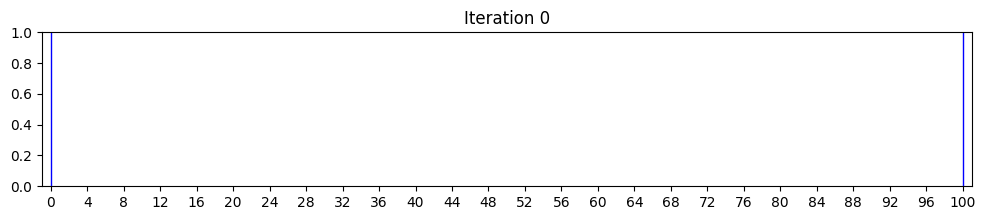

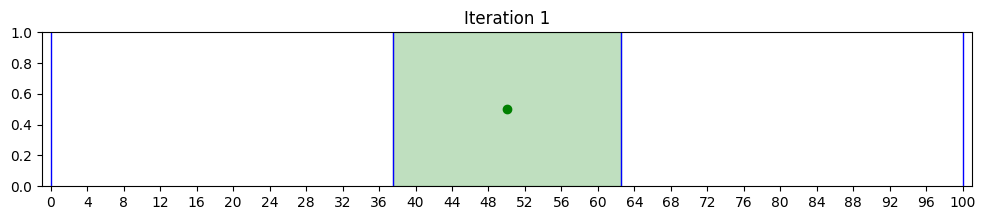

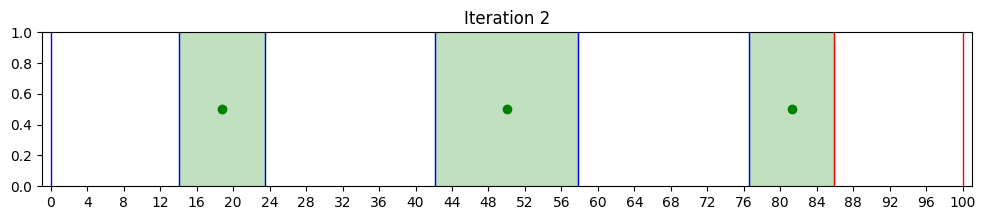

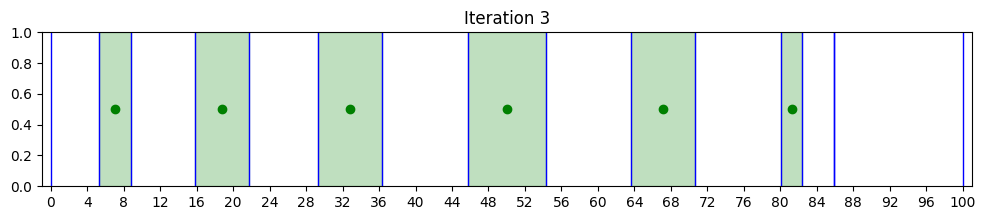

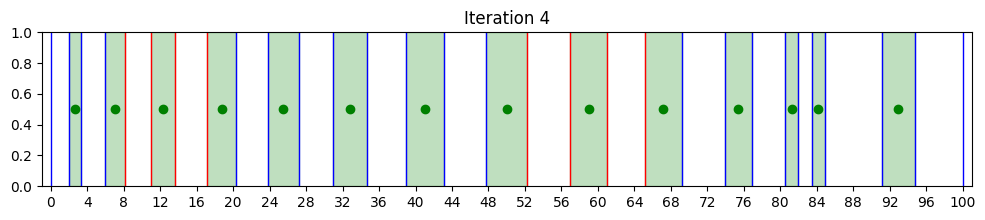

In [3]:
intervals = [[(0, 100)]]
excludedMasks = [[0]]
sampledMasks = [[0]]
plt.figure(figsize=(12, 2))
for j in range(len(intervals[0])):
    L, R = intervals[0][j]
    if excludedMasks[0][j]:
        plt.vlines(L, 0, 1, color='red', linewidth=1)
        plt.vlines(R, 0, 1, color='red', linewidth=1)
    else:
        if sampledMasks[0][j]:
            plt.plot(0.5*(L+R), 0.5, marker='o', color='green', markersize=6)
            plt.fill_betweenx([0, 1], L, R, color='green', alpha=0.25)
        else:
            plt.vlines(L, 0, 1, color='blue', linewidth=1)
            plt.vlines(R, 0, 1, color='blue', linewidth=1)
plt.xlim(-1, 101)    
plt.ylim(0, 1)
plt.xticks(np.linspace(0, 100, 26))
plt.title("Iteration 0")
plt.show()
for i in range(4):
    intervals_i, sampledMasks_i, excludedMasks_i = split_intervals(intervals[i], excludedMasks[i])
    for j in range(len(excludedMasks_i)):
        if not(sampledMasks_i[j]):
            np.random.seed(i+j)
            excludedMasks_i[j] = bool(np.random.choice([True, False], p=[0.15, 0.85]))
    
    intervals.append(intervals_i)
    excludedMasks.append(excludedMasks_i)
    sampledMasks.append(sampledMasks_i)
    plt.figure(figsize=(12, 2))
    for j in range(len(intervals_i)):
        L, R = intervals_i[j]
        if excludedMasks_i[j]:
            plt.vlines(L, 0, 1, color='red', linewidth=1)
            plt.vlines(R, 0, 1, color='red', linewidth=1)
        else:
            if sampledMasks_i[j]:
                plt.plot(0.5*(L+R), 0.5, marker='o', color='green', markersize=6)
                plt.fill_betweenx([0, 1], L, R, color='green', alpha=0.25)
            else:
                plt.vlines(L, 0, 1, color='blue', linewidth=1)
                plt.vlines(R, 0, 1, color='blue', linewidth=1)
    plt.xlim(-1, 101)    
    plt.ylim(0, 1)
    plt.xticks(np.linspace(0, 100, 26))
    plt.title(f"Iteration {i+1}")
    plt.show()

#### 1.1.3 - MD Interval Partition

In [32]:
def hyperboxes_partition(boxes: np.ndarray,
                         excludeMask: np.ndarray,
                         directionOrders: np.ndarray = None,
                         atol: float = 1e-12):
    """
    Ordered m-D partition that:
      • Preserves union exactly.
      • Splits along axes in specified order.
      • At each axis, only the box on the 'center path' is split; others are left intact.
      • 'sampled' is True iff an output box center coincides with its input box center
        and it is not excluded.

    Args
    ----
    boxes : (n, m, 2) float
        For each input i: [L_i, R_i] (,m) axis-aligned bounds.
    excludeMask : (n,) bool
        True if the input box is excluded (passes through unchanged).
    directionOrders : (n,m) int
        For each input i: [d_j (m)] order of axis in which each box will be partitioned.
        Default is [d_1, d_2,...,d_m] for all boxes.

    Returns
    -------
    boxesOut           : (K, m, 2) float
    sampleMaskOut     : (K,) bool
        True exactly for boxes whose center equals the center of their original input
        and are not excluded.
    excludeMaskOut : (K,) bool
        Expanded exclusion mask; children inherit the parent's exclusion.
    """
    boxes = np.asarray(boxes, float)
    excl = np.asarray(excludeMask, bool)
    n, m, two = boxes.shape
    assert two == 2, "boxes must have shape (n,m,2)"
    if directionOrders is not None:
        dirOrd = np.asarray(directionOrders, int)
        nn, mm = dirOrd.shape
        assert n == nn and m == mm, "directionOrders must have shape (n,m)"
    else:
        dirOrd = np.array([list(range(m))]*n)


    out_boxes = []
    out_parent = []  # track which input each output came from (for sampled mask)
    out_excl = []

    # Centers of inputs
    centers_in = 0.5 * (boxes[:, :, 0] + boxes[:, :, 1])  # (n, m)

    for i in range(n):
        if excl[i]:
            # Excluded → pass through
            out_boxes.append(boxes[i].copy())
            out_parent.append(i)
            out_excl.append(True)
            continue

        # Start with the single input box; split only along the center path
        boxes_i = [boxes[i].copy()]
        idx = 0 # Box index to split
        
        # Axis split order
        splitOrder = dirOrd[i]

        for d in splitOrder:
            # Find the unique box in the center path
            b = boxes_i.pop(idx)
            L, R = b[:,0].copy(), b[:,1].copy() # Left and right bounds of the box
            c = centers_in[i, d] # Center of the box in axis d
            # Start partition
            left, right = c - L[d], R[d] - c # Left and right distance to bounds in axis d
            w = 0.5 * min(left, right)  # full width of the center window on axis d
            # If width is below a tolerance we will not partition
            if not np.isfinite(w) or w <= atol:
                # No meaningful split on this axis
                boxes_i.insert(idx, b)
                continue

            l = c - 0.5 * w  # left boundary of center window on axis d
            r = c + 0.5 * w  # right boundary of center window on axis d

            # Build the three replacements along axis d (left residual, center, right residual)
            left_box = b.copy();  left_box[d, 1] = l
            mid_box  = b.copy();  mid_box[d, 0] = l; mid_box[d, 1] = r
            right_box= b.copy();  right_box[d, 0] = r

            boxes_i[idx:idx] = [left_box, mid_box, right_box]
            
            # We add left residual so box in center path increases by one
            idx += 1

        # Collect results for input i
        for b in boxes_i:
            out_boxes.append(b)
            out_parent.append(i)
            out_excl.append(False)

    boxesOut = np.array(out_boxes, float)
    excludeMaskOut = np.array(out_excl, bool)
    parents = np.array(out_parent, int)

    # sampled: output center equals (within tol) the center of its own parent input
    centers_out = 0.5 * (boxesOut[:, :, 0] + boxesOut[:, :, 1])
    sampleMaskOut = np.array(
        [(not excludeMaskOut[k]) and np.allclose(centers_out[k], centers_in[parents[k]], atol=atol) for k in range(len(boxesOut))],
        dtype=bool
    )

    return boxesOut, sampleMaskOut, excludeMaskOut

def hyperboxes_midpoints(boxes: np.ndarray):
    """
    Return midpoints if input boxes.
    
    Args
    ----
    boxes : (n, m, 2) float
        For each input i: [L_i, R_i] (,m) axis-aligned bounds.

    Returns
    -------
    midsOut           : (n, m) float
    """
    midsOut = 0.5 * (boxes[:, :, 0] + boxes[:, :, 1])
    return midsOut

def hypermask(boxes: np.ndarray, X: np.ndarray):
    """
    Return a boolean mask marking which points in X lie inside at least one
    hyperbox from `boxes`. Bounds are inclusive.

    Parameters
    ----------
    boxes : array_like, shape (n, m, 2) or (m, 2)
        n hyperboxes in m dimensions. For each box, boxes[d, 0] is the left
        bound in dimension d and boxes[d, 1] is the right bound.
    X : array_like, shape (k, m)
        k points in the same m-dimensional space.

    Returns
    -------
    mask : ndarray, shape (k,), dtype=bool
        True if the point lies in any hyperbox (inclusive bounds).
    """
    boxes = np.asarray(boxes)
    X = np.asarray(X)

    if boxes.ndim != 3 or boxes.shape[-1] != 2:
        raise ValueError("`boxes` must have shape (n, m, 2).")
    if X.ndim != 2 or X.shape[1] != boxes.shape[1]:
        raise ValueError(f"`X` must have shape (k, {boxes.shape[1]}).")

    left, right = boxes[..., 0], boxes[..., 1]  # (n, m) each

    ge_left = X[:, None, :] >= left[None, :, :]
    le_right = X[:, None, :] <= right[None, :, :]

    inside_per_box = np.logical_and(ge_left, le_right).all(axis=-1)  # (k, n)
    return inside_per_box.any(axis=1)

#### 1.1.4 - MD Partition Test in 1D

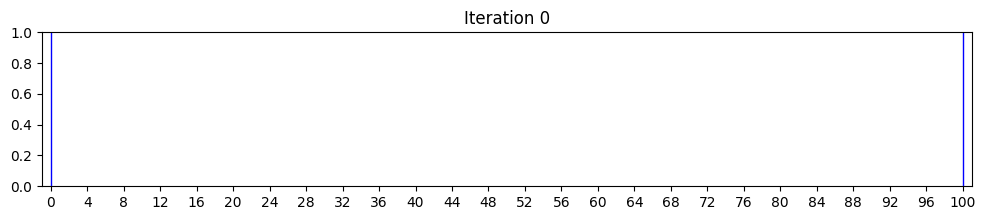

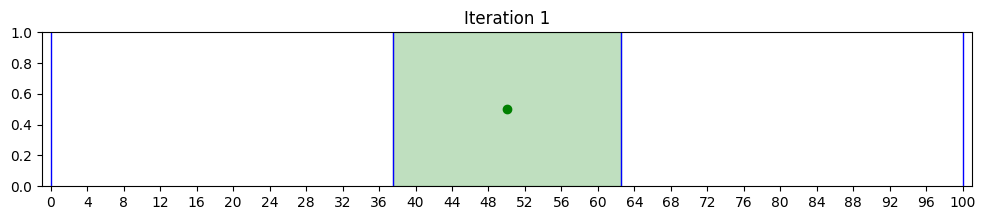

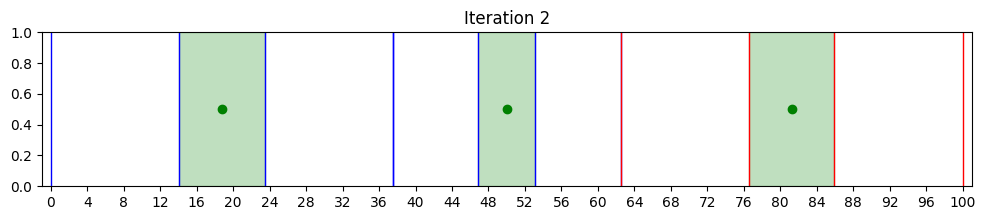

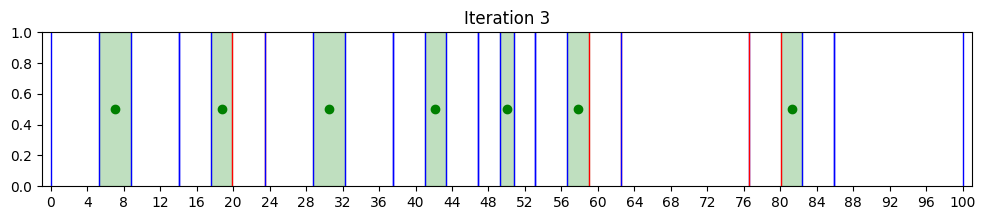

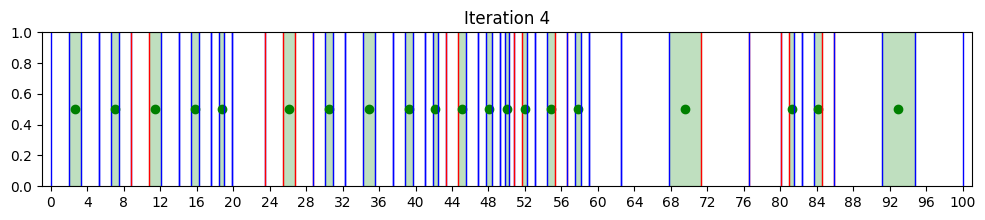

In [5]:
mdIntervals = [np.array([[[0, 100]]])]
mdExcMasks = [np.array([0])]
mdSampMasks = [np.array([0])]
plt.figure(figsize=(12, 2))
for j in range(len(mdIntervals[0])):
    box = mdIntervals[0][j]
    L, R = box[:,0], box[:,1]
    if mdExcMasks[0][j]:
        plt.vlines(L, 0, 1, color='red', linewidth=1)
        plt.vlines(R, 0, 1, color='red', linewidth=1)
    else:
        if mdSampMasks[0][j]:
            plt.plot(0.5*(L+R), 0.5, marker='o', color='green', markersize=6)
            plt.fill_betweenx([0, 1], L, R, color='green', alpha=0.25)
        else:
            plt.vlines(L, 0, 1, color='blue', linewidth=1)
            plt.vlines(R, 0, 1, color='blue', linewidth=1)   
plt.ylim(0, 1)
plt.xlim(-1, 101)
plt.xticks(np.linspace(0, 100, 26))
plt.title("Iteration 0")
plt.show()
for i in range(4):
    intervals_i, sampleMasks_i, excludeMasks_i = hyperboxes_partition(mdIntervals[i], mdExcMasks[i])
    for j in range(len(excludeMasks_i)):
        if not(sampleMasks_i[j]):
            np.random.seed(i+j)  # For reproducibility
            excludeMasks_i[j] = bool(np.random.choice([True, False], p=[0.15, 0.85]))
    
    mdIntervals.append(intervals_i)
    mdExcMasks.append(excludeMasks_i)
    mdSampMasks.append(sampleMasks_i)
    plt.figure(figsize=(12, 2))
    for j in range(len(intervals_i)):
        box = intervals_i[j]
        L, R = box[:,0], box[:,1]
        if excludeMasks_i[j]:
            plt.vlines(L, 0, 1, color='red', linewidth=1)
            plt.vlines(R, 0, 1, color='red', linewidth=1)
        else:
            if sampleMasks_i[j]:
                plt.plot(0.5*(L+R), 0.5, marker='o', color='green', markersize=6)
                plt.fill_betweenx([0, 1], L, R, color='green', alpha=0.25)
            else:
                plt.vlines(L, 0, 1, color='blue', linewidth=1)
                plt.vlines(R, 0, 1, color='blue', linewidth=1)
    plt.xlim(-1, 101)    
    plt.ylim(0, 1)
    plt.xticks(np.linspace(0, 100, 26))
    plt.title(f"Iteration {i+1}")
    plt.show()

#### 1.1.5 - MD Partition Test in 2D

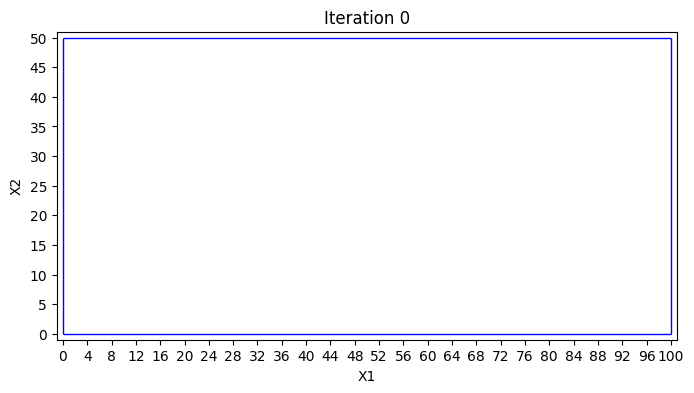

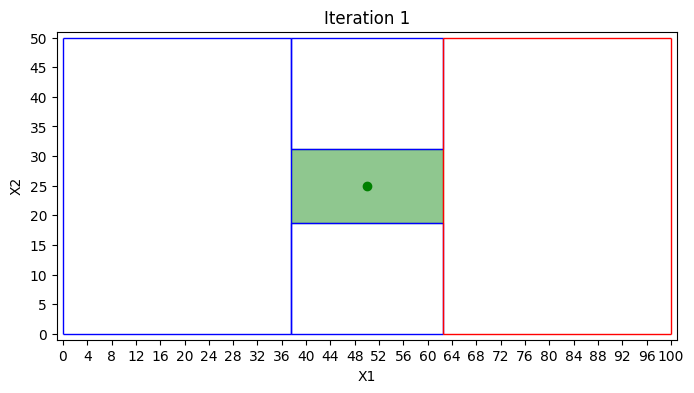

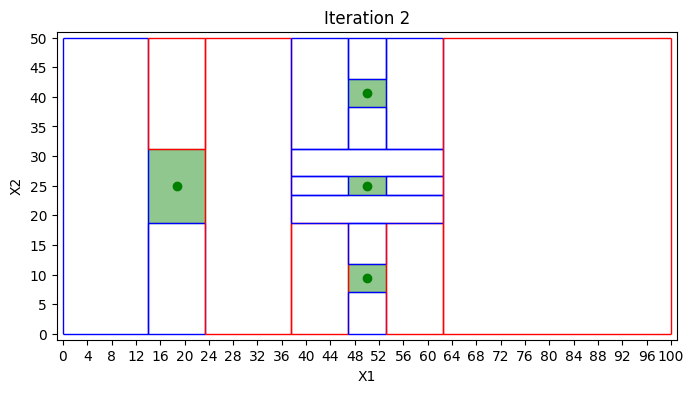

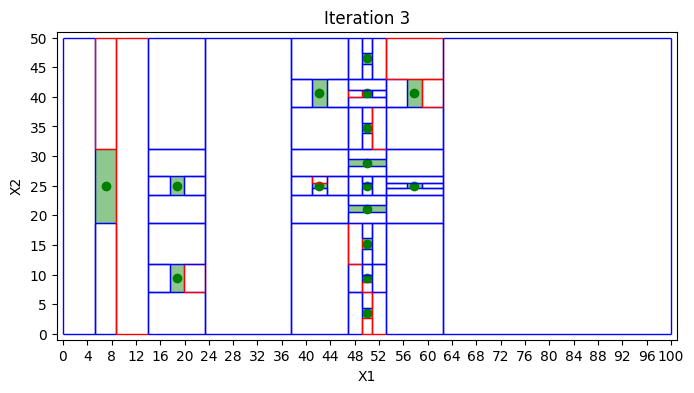

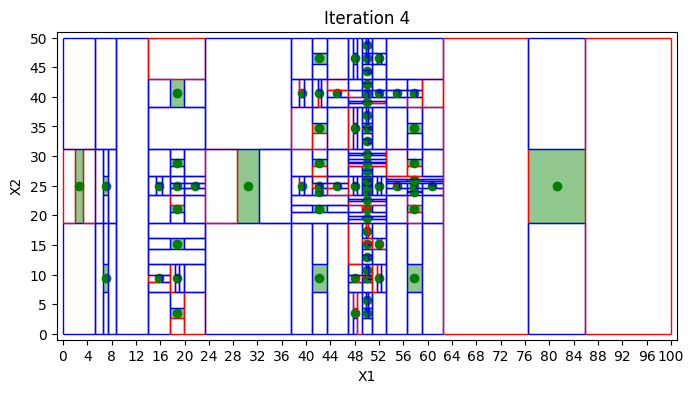

In [6]:
mdIntervals = [np.array([[[0, 100], 
                          [0, 50]]])]
mdExcMasks = [np.array([0])]
mdSampMasks = [np.array([0])]
plt.figure(figsize=(8, 4))
for j in range(len(mdIntervals[0])):
    box = mdIntervals[0][j]
    Lx, Ly = box[:,0]
    Rx, Ry = box[:,1]
    if mdExcMasks[0][j]:
        plt.vlines(Lx, Ly, Ry, color='red', linewidth=1)
        plt.vlines(Rx, Ly, Ry, color='red', linewidth=1)
        plt.hlines(Ly, Lx, Rx, color='red', linewidth=1)
        plt.hlines(Ry, Lx, Rx, color='red', linewidth=1)
    else:
        if mdSampMasks[0][j]:
            plt.plot(0.5*(Lx+Rx), 0.5*(Ly+Ry), marker='o', color='green', markersize=6)
            plt.fill_betweenx([Ly, Ry], Lx, Rx, color='green', alpha=0.25)
            plt.fill_between([Lx, Rx], Ly, Ry, color='green', alpha=0.25)
        else:
            plt.vlines(Lx, Ly, Ry, color='blue', linewidth=1)
            plt.vlines(Rx, Ly, Ry, color='blue', linewidth=1)
            plt.hlines(Ly, Lx, Rx, color='blue', linewidth=1)
            plt.hlines(Ry, Lx, Rx, color='blue', linewidth=1)
plt.xlim(-1, 101)
plt.ylim(-1,51)
plt.xticks(np.linspace(0, 100, 26))
plt.yticks(np.linspace(0, 50, 11))
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Iteration 0")
plt.show()
for i in range(4):
    n,m,_ = mdIntervals[i].shape
    rng = np.random.default_rng(i)
    dirOrd = np.vstack([rng.permutation(m) for _ in range(n)])
    intervals_i, sampleMasks_i, excludeMasks_i = hyperboxes_partition(mdIntervals[i], mdExcMasks[i], dirOrd)
    
    for j in range(len(excludeMasks_i)):
        if not(sampleMasks_i[j]):
            np.random.seed(i+j+100)  # For reproducibility
            excludeMasks_i[j] = bool(np.random.choice([True, False], p=[0.15, 0.85]))
    
    mdIntervals.append(intervals_i)
    mdExcMasks.append(excludeMasks_i)
    mdSampMasks.append(sampleMasks_i)

    plt.figure(figsize=(8, 4))
    for j in range(len(intervals_i)):
        box = intervals_i[j]
        Lx, Ly = box[:,0]
        Rx, Ry = box[:,1]
        if excludeMasks_i[j]:
            plt.vlines(Lx, Ly, Ry, color='red', linewidth=1)
            plt.vlines(Rx, Ly, Ry, color='red', linewidth=1)
            plt.hlines(Ly, Lx, Rx, color='red', linewidth=1)
            plt.hlines(Ry, Lx, Rx, color='red', linewidth=1)
        else:
            if sampleMasks_i[j]:
                plt.plot(0.5*(Lx+Rx), 0.5*(Ly+Ry), marker='o', color='green', markersize=6)
                plt.fill_betweenx([Ly, Ry], Lx, Rx, color='green', alpha=0.25)
                plt.fill_between([Lx, Rx], Ly, Ry, color='green', alpha=0.25)
            else:
                plt.vlines(Lx, Ly, Ry, color='blue', linewidth=1)
                plt.vlines(Rx, Ly, Ry, color='blue', linewidth=1)
                plt.hlines(Ly, Lx, Rx, color='blue', linewidth=1)
                plt.hlines(Ry, Lx, Rx, color='blue', linewidth=1)

    plt.xlim(-1, 101)
    plt.ylim(-1,51)
    plt.xticks(np.linspace(0, 100, 26))
    plt.yticks(np.linspace(0, 50, 11))
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(f"Iteration {i+1}")
    plt.show()

### 1.2 - Interval Arithmetics

In [7]:
def mul_interval_scalar(c: float, lo: float, hi: float):
    """Return bounds for c*[lo,hi]."""
    a, b = c * lo, c * hi
    return (min(a, b), max(a, b))

def add_intervals(a_lo, a_hi, b_lo, b_hi):
    """Return bounds for [a_lo,a_hi] + [b_lo,b_hi]."""
    return (a_lo + b_lo, a_hi + b_hi)

def sub_intervals(a_lo, a_hi, b_lo, b_hi):
    """Return bounds for [a_lo,a_hi] - [b_lo,b_hi]."""
    return (a_lo - b_hi, a_hi - b_lo)

def square_interval(lo: float, hi: float):
    """Return bounds for z^2 with z in [lo,hi]."""
    if lo <= 0.0 <= hi:
        return (0.0, max(lo * lo, hi * hi))
    else:
        return (min(lo * lo, hi * hi), max(lo * lo, hi * hi))
    
def forward_solve_interval_L(Lmat, Kmins, Kmaxs):
    """
    Given lower-triangular L with positive diagonal (Cholesky),
    and componentwise bounds k_i ∈ [Kmin_i, Kmax_i],
    compute tight interval bounds v_j ∈ [v_lo[j], v_hi[j]] for the solution of L v = k.

    Recurrence:
      v_1 = k_1 / L_11
      v_j = (k_j - sum_{i<j} L_{j,i} v_i) / L_{j,j}
    """
    L = np.asarray(Lmat, float)
    n = L.shape[0]
    v_lo = np.zeros(n)
    v_hi = np.zeros(n)

    for j in range(n):
        # Sum S_j = Σ_{i<j} L_{j,i} v_i, with each term interval-bounded
        S_lo, S_hi = 0.0, 0.0
        for i in range(j):
            lij = L[j, i]
            t_lo, t_hi = mul_interval_scalar(lij, v_lo[i], v_hi[i])
            S_lo, S_hi = add_intervals(S_lo, S_hi, t_lo, t_hi)

        # Numerator interval: N_j = k_j - S_j
        Kj_lo, Kj_hi = Kmins[j], Kmaxs[j]
        N_lo, N_hi = sub_intervals(Kj_lo, Kj_hi, S_lo, S_hi)

        # Divide by positive L_{j,j}
        Ljj = L[j, j]
        # since Ljj > 0 (Cholesky), division preserves order
        v_lo[j] = N_lo / Ljj
        v_hi[j] = N_hi / Ljj

    return v_lo, v_hi

### 1.3 - Std Normal CDF and PDF

In [8]:
def Phi(z: float) -> float:
    """Standard normal CDF."""
    return 0.5 * (1.0 + erf(z / sqrt(2.0)))

def phi(z: float) -> float:
    """Standard normal PDF."""
    return (1.0 / sqrt(2.0 * pi)) * exp(-0.5 * z * z)

### 1.4 - RBF Kernel Bounds

#### 1.4.1 - 1D

In [9]:
#def rbf_K_interval(L: float, R: float, xi: float, sigma_f2: float, ell: float):
def rbf_K_interval(L: float, R: float, xi: float, gp: GaussianProcessRegressor):
    """
    Compute [K_{i,min}, K_{i,max}] for 
    k(x,xi)=sigma_f^2*exp(-(x-xi)^2/(2 ell^2)), 
    x in [L,R] and gp.kernel_ is RBF kernel
    trained with all the xi points.
    """
    # Bounds for D_i
    Dmin = min(abs(L - xi), abs(R - xi))
    Dmax = max(abs(L - xi), abs(R - xi))
    # Calculate Kmin and Kmax using kernel from gp
    Kall = gp.kernel_([[Dmin],[Dmax]],[[0],[0]])
    KminGP = Kall[1,0]
    KmaxGP = Kall[0,0]
    # S_i = D_i^2 / (2 ell^2)
    #Smin = (Dmin ** 2) / (2.0 * ell ** 2)
    #Smax = (Dmax ** 2) / (2.0 * ell ** 2)
    # E_i = exp(-S_i) is decreasing in S_i
    #Emin = exp(-Smax)
    #Emax = exp(-Smin)
    # K_i = sigma_f^2 * E_i
    #Kmin = sigma_f2 * Emin
    #Kmax = sigma_f2 * Emax
    #return float(Kmin), float(Kmax), float(KminGP), float(KmaxGP)
    return float(KminGP), float(KmaxGP)

#### 1.4.2 - MD

In [10]:
def rbf_K_interval_MD(
    L: np.ndarray, R: np.ndarray, xi: np.ndarray, gp: GaussianProcessRegressor
) -> Tuple[float, float]:
    """
    Bounds [K_min, K_max] for k(x, xi) of an RBF with x in the box [L, R].
    Works for sklearn kernels like ConstantKernel*RBF and (+ WhiteKernel).
    """
    # Ensure inputs are 1D arrays of same length
    L = np.asarray(L, dtype=float).ravel()
    R = np.asarray(R, dtype=float).ravel()
    xi = np.asarray(xi, dtype=float).ravel()
    assert L.shape == R.shape == xi.shape, "L, R, xi must have same shape"
    assert np.all(L <= R), "Each component must satisfy L[j] <= R[j]"

    # Compute dmin and dmax for each dimension
    dmins = np.maximum(np.maximum(L-xi, xi-R), 0)  # Distance to box if outside, else 0
    dmaxs = np.maximum(np.abs(L - xi), np.abs(R - xi))  # Max distance to box corners
    #print(dmins, dmaxs)

    # Bounds for D_i
    Dmin = np.linalg.norm(dmins)  # Minimum distance to box
    Dmax = np.linalg.norm(dmaxs)  # Maximum distance to box corners
    
    # Calculate Kmin and Kmax using kernel from gp
    Kall = gp.kernel_([[Dmin],[Dmax]],[[0],[0]])
    KmaxGP, KminGP = Kall.diagonal()
    
    return float(KminGP), float(KmaxGP)

In [11]:
X = np.array([[0, 0, 0, 0],[1, 1, 1, 1], [0.5, 0.5, 0.5, 0.5]])
y = np.array([0, 1, 0.5])
gp = GaussianProcessRegressor(kernel=ConstantKernel(1.0)*RBF(length_scale=1.0)).fit(X, y)

rbf_K_interval_MD([0.25, 0.25, 0.25, 0.25], [0.4, 0.4, 0.4, 0.4], [0.2, 0.3, 0.45, 0.4], gp)

(3207.269975325884, 3207.2744550254547)

### 1.5 - GP Posterior Mean Bounds

#### 1.5.1 - 1D

In [12]:
#def gp_mu_interval_bounds(X: np.ndarray, y: np.ndarray, L: float, R: float, sigma_f2: float, ell: float, sigma_n2=0.0: float):
def gp_mu_interval_bounds(L: float, R: float, gp: GaussianProcessRegressor):
    """
    Compute [μ_lo, μ_hi] for 
    μ(x)=k(x)^T α, α = L^{-T} \\ (L \\ y), 
    x in [L,R].
    """
    #X = np.asarray(X, dtype=float).ravel()
    X = np.asarray(gp.X_train_, dtype=float).ravel()
    #y = np.asarray(y, dtype=float).ravel()
    #y = np.asarray(gp.y_train_, dtype=float).ravel()
    n = len(X)

    # Build K(X,X)
    #D2 = (X[:, None] - X[None, :]) ** 2
    #K = sigma_f2 * np.exp(- D2 / (2.0 * ell ** 2))

    # α = (K + σ_n^2 I)^(-1) y
    #A = np.linalg.solve(K + sigma_n2 * np.eye(n), np.eye(n))   # (K+σ_n^2 I)^{-1}
    #alpha = A @ y
    alpha = gp.alpha_.ravel()
    #print("alpha:", alpha)

    # Componentwise kernel intervals
    Kmins = np.empty(n, dtype=float)
    Kmaxs = np.empty(n, dtype=float)
    for i, xi in enumerate(X):
        Kmins[i], Kmaxs[i] = rbf_K_interval(L, R, xi, gp)

    # μ bounds: sum of α_i * K_i with interval multiplication
    mu_lo = 0.0
    mu_hi = 0.0
    for a, kmin, kmax in zip(alpha, Kmins, Kmaxs):
        #print("a, kmin, kmax:", a, kmin, kmax)
        #lo_i = min(a * kmin, a * kmax)
        #hi_i = max(a * kmin, a * kmax)

        lo_i, hi_i = mul_interval_scalar(a, kmin, kmax)
        mu_lo += lo_i
        mu_hi += hi_i

    #return float(mu_lo), float(mu_hi), A, Kmins, Kmaxs
    #print("mu_lo, mu_hi:", mu_lo, mu_hi)
    return float(mu_lo), float(mu_hi), Kmins, Kmaxs

#### 1.5.2 - MD

In [105]:
def gp_mu_interval_bounds_MD(
    L: np.ndarray, R: np.ndarray, gp: GaussianProcessRegressor
) -> Tuple[float, float, np.ndarray, np.ndarray]:
    """
    Compute [μ_lo, μ_hi] for 
    μ(x)=k(x)^T α, α = L^{-T} \\ (L \\ y), 
    x in [L,R].
    """
    X = np.asarray(gp.X_train_, dtype=float)
    n = X.shape[0]
    alpha = gp.alpha_.ravel()
    #print("alpha:", alpha)

    # Componentwise kernel intervals
    Kmins = np.empty(n, dtype=float)
    Kmaxs = np.empty(n, dtype=float)
    for i, xi in enumerate(X):
        Kmins[i], Kmaxs[i] = rbf_K_interval_MD(L, R, xi, gp)
        #print(xi)

    # μ bounds: sum of α_i * K_i with interval multiplication
    mu_lo = 0.0
    mu_hi = 0.0
    for a, kmin, kmax in zip(alpha, Kmins, Kmaxs):
        #print("a, kmin, kmax:", a, kmin, kmax)
        #lo_i = min(a * kmin, a * kmax)
        #hi_i = max(a * kmin, a * kmax)

        lo_i, hi_i = mul_interval_scalar(a, kmin, kmax)
        mu_lo += lo_i
        mu_hi += hi_i

    y_train_std = np.asarray(gp._y_train_std).item()
    y_train_mean = np.asarray(gp._y_train_mean).item()

    mu_lo = y_train_std*float(mu_lo) + y_train_mean
    mu_hi = y_train_std*float(mu_hi) + y_train_mean

    #return float(mu_lo), float(mu_hi), A, Kmins, Kmaxs
    #print("mu_lo, mu_hi:", mu_lo, mu_hi)
    return mu_lo, mu_hi, Kmins, Kmaxs

In [14]:
X = np.array([[0, 0, 0, 0],[1, 1, 1, 1], [0.5, 0.5, 0.5, 0.5]])
y = np.array([0, 1, 0.5])
gp = GaussianProcessRegressor(kernel=ConstantKernel(1.0)*RBF(length_scale=1.0)).fit(X, y)

gp_mu_interval_bounds_MD([0.25, 0.25, 0.25, 0.25], [0.4, 0.4, 0.4, 0.4], gp)

(0.1975059194228379,
 0.4524903982746764,
 array([3207.24799363, 3207.18090353, 3207.26424549]),
 array([3207.26424549, 3207.21465676, 3207.27299652]))

### 1.6 - GP Posterior Standard Deviation Bounds

In [15]:
#def gp_sigma_interval_bounds(A: np.ndarray, Kmins: np.ndarray, Kmaxs: np.ndarray, sigma_f2: float):
def gp_sigma_interval_bounds(Kmins: np.ndarray, Kmaxs: np.ndarray, gp: GaussianProcessRegressor):
    """
    Given L = cholesky(K + σ_n^2 I) and per-component kernel 
    intervals [Kmin_i,Kmax_i] (nonnegative),
    bound v_j ∈ [v_lo[j], v_hi[j]] for the solution of L v = k, and then
    bound Q = ||v||^2,
    then σ^2 = σ_f^2 - Q, and finally σ ∈ [sqrt(max(0,σ^2_lo)), sqrt(max(0,σ^2_hi))].
    """
    #A = np.asarray(A, dtype=float)
    #n = A.shape[0]
    Kmins = np.asarray(Kmins, dtype=float)
    Kmaxs = np.asarray(Kmaxs, dtype=float)

    # Extract σ_f^2 from gp
    gp_params = gp.kernel_.get_params()
    sigma_f2 = float(gp_params['k1__constant_value'])

    # Extract L = cholesky(K + σ_n^2 I) from gp
    L_ = gp.L_

    # Calculate bounds v_j ∈ [v_lo[j], v_hi[j]] for the solution of L v = k
    v_lo, v_hi = forward_solve_interval_L(L_, Kmins, Kmaxs)

    # Diagonal terms
    #I_lo = 0.0
    #I_hi = 0.0
    #for i in range(n):
    #    aii = A[i, i]
    #    t1 = aii * (Kmins[i] ** 2)
    #    t2 = aii * (Kmaxs[i] ** 2)
    #    I_lo += min(t1, t2)
    #    I_hi += max(t1, t2)

    # Off-diagonal terms (i<j), with nonnegative intervals so [k_i*k_j] = [kmin_i*kmin_j, kmax_i*kmax_j]
    #O_lo = 0.0
    #O_hi = 0.0
    #for i in range(n):
    #    ki_min, ki_max = Kmins[i], Kmaxs[i]
    #    for j in range(i + 1, n):
    #        aij = A[i, j]
    #        kj_min, kj_max = Kmins[j], Kmaxs[j]
    #        p_min = ki_min * kj_min
    #        p_max = ki_max * kj_max
    #        t1 = 2.0 * aij * p_min
    #        t2 = 2.0 * aij * p_max
    #        O_lo += min(t1, t2)
    #        O_hi += max(t1, t2)

    #Q_min = I_lo + O_lo
    #Q_max = I_hi + O_hi

    # Q interval = sum of squares intervals (IA addition)
    Q_lo, Q_hi = 0.0, 0.0
    for lo, hi in zip(v_lo, v_hi):
        s_lo, s_hi = square_interval(lo, hi)
        Q_lo += s_lo
        Q_hi += s_hi

    # σ^2 interval: [max(0, σ_f^2 - Q_max), max(0, σ_f^2 - Q_min)]
    sig2_lo = max(0.0, sigma_f2 - Q_hi)
    sig2_hi = max(0.0, sigma_f2 - Q_lo)

    # σ interval by monotonicity of sqrt
    sig_lo = sqrt(sig2_lo)
    sig_hi = sqrt(sig2_hi)
    return float(sig_lo), float(sig_hi), float(Q_lo), float(Q_hi), (v_lo, v_hi)

### 1.7 - EI Bounds

In [16]:
def ei_interval_explicit(mu_bounds, sigma_bounds, gp: GaussianProcessRegressor):
    """
    Explicit IA bounds for EI on an interval using:
      EI = N * Phi(Z) + σ * phi(Z),  with N=f_min - μ,  Z=N/σ.
    Inputs:
      f_min        : current best observed value
      mu_bounds    : (μ_lo, μ_hi)
      sigma_bounds : (σ_lo, σ_hi) with σ_lo >= 0
    Returns:
      (EI_lo, EI_hi)
    """
    mu_lo, mu_hi = float(mu_bounds[0]), float(mu_bounds[1])
    sig_lo, sig_hi = float(sigma_bounds[0]), float(sigma_bounds[1])

    # Extract f_min from gp
    y = np.asarray(gp.y_train_, dtype=float).ravel()
    f_min = np.min(y)

    # Interval for N = f_min - μ
    N_min = f_min - mu_hi
    N_max = f_min - mu_lo

    # If σ_lo == 0, use a safe enclosure: EI increases with σ (for fixed μ), so
    # lower bound at σ=0; upper bound at (μ=μ_lo, σ=σ_hi).
    if sig_lo == 0.0:
        EI_lo = max(0.0, N_min)  # EI(μ=μ_hi, σ=0) is a lower bound
        if sig_hi > 0.0:
            Z_hi = (f_min - mu_lo) / sig_hi
            EI_hi = (f_min - mu_lo) * Phi(Z_hi) + sig_hi * phi(Z_hi)
            # Ensure nonnegativity
            EI_hi = max(EI_hi, EI_lo)
        else:
            # σ_hi is also zero → EI is exactly max(0, N)
            EI_hi = max(0.0, N_max)
        return float(EI_lo), float(EI_hi)

    # Otherwise, proceed with explicit IA through Z, Phi, phi
    # J = 1/σ ∈ [1/σ_hi, 1/σ_lo]
    J_min = 1.0 / sig_hi
    J_max = 1.0 / sig_lo

    # Z = N * J, full interval product (four corners)
    S = [N_min * J_min, N_min * J_max, N_max * J_min, N_max * J_max]
    Z_min, Z_max = min(S), max(S)

    # Phi(Z) interval (monotone)
    F_min = Phi(Z_min)
    F_max = Phi(Z_max)

    # phi(Z) interval (unimodal, symmetric)
    P_candidates = [phi(Z_min), phi(Z_max)]
    if Z_min <= 0.0 <= Z_max:
        P_candidates.append(phi(0.0))
    P_min = min(P_candidates)
    P_max = max(P_candidates)

    # U = N * Phi(Z)
    U_candidates = [
        N_min * F_min, N_min * F_max,
        N_max * F_min, N_max * F_max
    ]
    U_min, U_max = min(U_candidates), max(U_candidates)

    # V = σ * phi(Z)
    V_candidates = [
        sig_lo * P_min, sig_lo * P_max,
        sig_hi * P_min, sig_hi * P_max
    ]
    V_min, V_max = min(V_candidates), max(V_candidates)

    # EI = U + V (interval addition)
    EImin = max(0.0, U_min + V_min)  # Ensure nonnegativity
    EImax = max(0.0, U_max + V_max)
    return float(EImin), float(EImax)

### 1.8 - One-call Wrapper

In [17]:
#def ei_bounds_on_interval(L: float, R: float, X: np.ndarray, y: np.ndarray, f_min: float, sigma_f2: float, ell: float, sigma_n2=0.0: float):
def ei_bounds_on_interval(L: float, R: float, gp: GaussianProcessRegressor):
    """
    Compute EI interval [EI_lo, EI_hi] on x in [L,R], following the LaTeX sections:
      1) kernel intervals -> 2) μ interval -> 3) σ interval -> 4) EI explicit IA
    Returns:
      dict with μ_bounds, σ_bounds, Q_bounds, EI_bounds
    """
    #mu_lo, mu_hi, A, Kmins, Kmaxs = gp_mu_interval_bounds(
    #    X, y, L, R, sigma_f2, ell, sigma_n2
    #)
    mu_lo, mu_hi, Kmins, Kmaxs = gp_mu_interval_bounds(L, R, gp)
    #sig_lo, sig_hi, Q_min, Q_max = gp_sigma_interval_bounds(
    #    A, Kmins, Kmaxs, sigma_f2
    #)
    sig_lo, sig_hi, Q_min, Q_max, _ = gp_sigma_interval_bounds(Kmins, Kmaxs, gp)
    #EI_lo, EI_hi = ei_interval_explicit(
    #    f_min, (mu_lo, mu_hi), (sig_lo, sig_hi)
    #)
    EI_lo, EI_hi = ei_interval_explicit((mu_lo, mu_hi), (sig_lo, sig_hi), gp)
    return {
        "mu_bounds": (mu_lo, mu_hi),
        "sigma_bounds": (sig_lo, sig_hi),
        "Q_bounds": (Q_min, Q_max),
        "EI_bounds": (EI_lo, EI_hi),
    }

## 2 - Testing Part by Part

### 2.1 - Toy function to minimize

In [19]:
def f(x):
    return (x - 2)**2 + np.sin(5*x)

### 2.2 - EI Function

In [20]:
def expected_improvement(X, gp, y_min):
    mu, sigma = gp.predict(X, return_std=True)
    sigma = sigma.reshape(-1,1)
    mu = mu.reshape(-1,1)
    with np.errstate(divide='warn'):
        Z = (y_min - mu) / sigma # to minimize
        ei = (y_min - mu) * norm.cdf(Z) + sigma * norm.pdf(Z) # to minimize
        ei[sigma==0.0] = 0.0
    return ei.ravel()

### 2.3 - Define domain

In [18]:
a, b = 0.0, 4.0

### 2.4 - Iteration 0

#### 2.4.1 - Sample at center

In [19]:
intervals0 = np.array([(a,b)])
excludedMask0Post = np.array([0], dtype=bool)
sampledMask0 = np.array([0], dtype=bool)
print("Iteration 0:")
print("intervals0:\n", intervals0)
print("sampledMask0:", sampledMask0.astype(int))
print("excludedMask0Post:", excludedMask0Post.astype(int))
print("x to sample:", interval_midpoints(intervals0[np.logical_not(excludedMask0Post)]))

X = interval_midpoints(intervals0[np.logical_not(excludedMask0Post)])
y = f(X)
print("y values:", y)

Iteration 0:
intervals0:
 [[0. 4.]]
sampledMask0: [0]
excludedMask0Post: [0]
x to sample: [[2.]]
y values: [[-0.54402111]]


#### 2.4.2 - Build GP

In [20]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6)
gp.fit(X, y)

,kernel,1**2 * RBF(length_scale=0.5)
,alpha,1e-06
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,RBF(length_scale=0.5)
,kernel__k1__constant_value,1.0


#### 2.4.3 - Plot

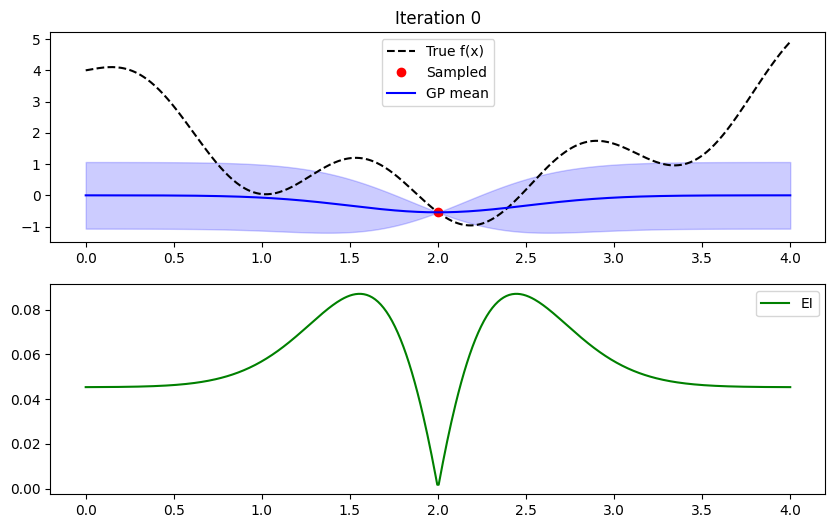

In [21]:
xx = np.linspace(a, b, 500).reshape(-1,1)
mu, sigma = gp.predict(xx, return_std=True)
ei = expected_improvement(xx, gp, np.min(y))

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(xx, f(xx), 'k--', label="True f(x)")
plt.plot(X, y, 'ro', label="Sampled")
plt.plot(xx, mu, 'b', label="GP mean")
plt.fill_between(xx.ravel(), mu-1.96*sigma, mu+1.96*sigma, alpha=0.2, color='b')
plt.legend(); plt.title("Iteration 0")

plt.subplot(2,1,2)
plt.plot(xx, ei, 'g', label="EI")
plt.legend()
plt.show()

#### 2.4.4 - Show EI interval estimation in 2 subdomains

In [22]:
iy = 0
intervals1, sampledMask1, excludedMask1Pre = split_intervals(intervals0, excludedMask0Post, a, b)
#for L,R in intervals1:
for i in range(len(intervals1)):
    L,R = intervals1[i]
    if sampledMask1[i]:
        print(f"\nInterval [{L:.2f}, {R:.2f}] Sampled")
        print(f"Value is f({0.5*(L+R):.2f}) = {float(y.ravel()[iy]):.4f}")
        iy += 1
    else:
        mask = ((xx >= L) & (xx <= R)).ravel()

    #f_min = float(y.min())
    #gp_params = gp.kernel_.get_params()
    #sigma_f2 = float(gp_params['k1__constant_value'])
    #ell = float(gp_params['k2__length_scale'])
    #sigma_n2 = gp.alpha

    #out = ei_bounds_on_interval(L, R, X, y, f_min, sigma_f2, ell, sigma_n2)
        out = ei_bounds_on_interval(L, R, gp)
        print(f"\nInterval [{L:.2f}, {R:.2f}]:")
        print("μ bounds :", out["mu_bounds"])
        print("Actual μ bounds :", (float(mu[mask].min()),float(mu[mask].max())))
        print("σ bounds :", out["sigma_bounds"])
        print("Q bounds :", out["Q_bounds"])
        print("EI bounds:", out["EI_bounds"])


Interval [0.00, 1.50]:
μ bounds : (-0.32996436840130267, -0.0001824981348684622)
Actual μ bounds : (-0.3293031180467831, -0.0001824981348684622)
σ bounds : (0.43253281370092495, 0.5440247415223307)
Q bounds : (3.3306130057116645e-08, 0.10887831776652981)
EI bounds: (0.0, 0.17853829205646704)

Interval [1.50, 2.50] Sampled
Value is f(2.00) = -0.5440

Interval [2.50, 4.00]:
μ bounds : (-0.32996436840130267, -0.0001824981348684622)
Actual μ bounds : (-0.3293031180467832, -0.0001824981348684622)
σ bounds : (0.43253281370092495, 0.5440247415223307)
Q bounds : (3.3306130057116645e-08, 0.10887831776652981)
EI bounds: (0.0, 0.17853829205646704)


#### 2.4.5 - Decide if Excluding Subdomains

In [23]:
excludedMask1Post = np.array([0,0,0], dtype=bool)

### 2.5 - Iteration 1

#### 2.5.1 - Sample function at the midpoint of the feasible subdomains

In [24]:
print("Iteration 1:")
print("intervals1:\n", intervals1)
print("sampledMask1:", sampledMask1.astype(int))
print("excludedMask1Pre:", excludedMask1Pre.astype(int))
print("bounded EI on:\n", intervals1[np.logical_and(np.logical_not(excludedMask1Pre),np.logical_not(sampledMask1))])
print("excludedMask1Post:", excludedMask1Post.astype(int))
print("x to sample:\n", interval_midpoints(intervals1[np.logical_not(excludedMask1Post)]))

X = interval_midpoints(intervals1[np.logical_not(excludedMask1Post)])
y = f(X)
print("y values:\n", y)

#X = np.vstack([X, X_new])
#y = np.vstack([y, y_new])

Iteration 1:
intervals1:
 [[0.  1.5]
 [1.5 2.5]
 [2.5 4. ]]
sampledMask1: [0 1 0]
excludedMask1Pre: [0 0 0]
bounded EI on:
 [[0.  1.5]
 [2.5 4. ]]
excludedMask1Post: [0 0 0]
x to sample:
 [[0.75]
 [2.  ]
 [3.25]]
y values:
 [[ 0.99093868]
 [-0.54402111]
 [ 1.04661815]]


#### 2.5.2 - Build GP

In [25]:
gp.fit(X, y)

,kernel,1**2 * RBF(length_scale=0.5)
,alpha,1e-06
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,RBF(length_scale=0.5)
,kernel__k1__constant_value,1.0


#### 2.5.3 - Plot

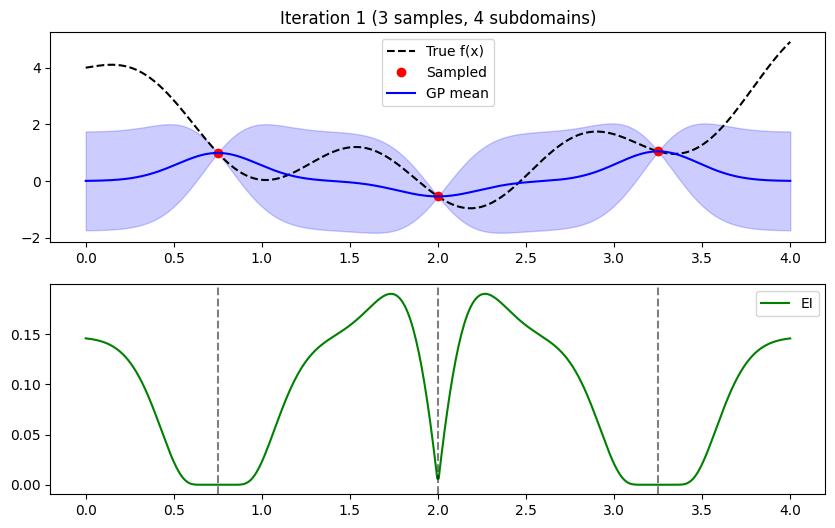

In [26]:
mu, sigma = gp.predict(xx, return_std=True)
ei = expected_improvement(xx, gp, np.min(y))

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(xx, f(xx), 'k--', label="True f(x)")
plt.plot(X, y, 'ro', label="Sampled")
plt.plot(xx, mu, 'b', label="GP mean")
plt.fill_between(xx.ravel(), mu-1.96*sigma, mu+1.96*sigma, alpha=0.2, color='b')
plt.legend(); plt.title("Iteration 1 (3 samples, 4 subdomains)")

plt.subplot(2,1,2)
plt.plot(xx, ei, 'g', label="EI")
for xvline in X.ravel():
    plt.axvline(xvline, color='k', ls='--', alpha=0.5) # subdomain split markers
#plt.axvline((a+x_c)/2, color='k', ls='--', alpha=0.5) # subdomain split markers
#plt.axvline((x_c+b)/2, color='k', ls='--', alpha=0.5)
#plt.axvline(x_c, color='k', ls=':')
plt.legend()
plt.show()

#### 2.5.4 - Show EI interval estimation in 4 subdomains

In [27]:
iy = 0
intervals2, sampledMask2, excludedMask2Pre = split_intervals(intervals1, excludedMask1Post, a, b)
for i in range(len(intervals2)):
    L,R = intervals2[i]
    if sampledMask2[i]:
        print(f"\nInterval [{L:.2f}, {R:.2f}] Sampled")
        print(f"Value is f({0.5*(L+R):.2f}) = {float(y.ravel()[iy]):.4f}")
        iy += 1
    else:
        mask = ((xx >= L) & (xx <= R)).ravel()

        out = ei_bounds_on_interval(L, R, gp)
        print(f"\nInterval [{L:.2f}, {R:.2f}]:")
        print("μ bounds :", out["mu_bounds"])
        print("Actual μ bounds :", (float(mu[mask].min()),float(mu[mask].max())))
        print("σ bounds :", out["sigma_bounds"])
        print("Q bounds :", out["Q_bounds"])
        print("EI bounds:", out["EI_bounds"])


Interval [0.00, 0.56]:
μ bounds : (0.00492428551015663, 0.7113197939471188)
Actual μ bounds : (0.0049242873838871975, 0.7078498742146806)
σ bounds : (0.6192655750250041, 0.8894520570534429)
Q bounds : (1.9536618213944372e-05, 0.4076546460037659)
EI bounds: (0.0, 0.2816002931718147)

Interval [0.56, 0.94] Sampled
Value is f(0.75) = 0.9909

Interval [0.94, 1.69]:
μ bounds : (-0.21635529725716712, 0.7113068457732948)
Actual μ bounds : (-0.21108947120647828, 0.7103612453327451)
σ bounds : (0.5080081439110731, 0.8894630110087559)
Q bounds : (5.0462052732309795e-08, 0.5330722241348415)
EI bounds: (0.0, 0.3293585185411524)

Interval [1.69, 2.31] Sampled
Value is f(2.00) = -0.5440

Interval [2.31, 3.06]:
μ bounds : (-0.21634129626799314, 0.7512749109695533)
Actual μ bounds : (-0.21107441110130531, 0.7502761840710644)
σ bounds : (0.5080081438594508, 0.8894630110382394)
Q bounds : (5.0409603766960834e-08, 0.5330722241872905)
EI bounds: (0.0, 0.3297973531676514)

Interval [3.06, 3.44] Sampled
Va

#### 2.5.5 - Decide if Excluding Subdomains

In [28]:
excludedMask2Post = np.array([0,0,0,0,0,0,0], dtype=bool)

### 2.6 - Iteration 2

#### 2.6.1 - Sample point at the midpoint of the feasible subdomains

In [29]:
print("Iteration 2:")
print("intervals2:\n", intervals2)
print("sampledMask2:", sampledMask2.astype(int))
print("excludedMask2Pre:", excludedMask2Pre.astype(int))
print("bounded EI on:\n", intervals2[np.logical_and(np.logical_not(excludedMask2Pre),np.logical_not(sampledMask2))])
print("excludedMask2Post:", excludedMask2Post.astype(int))
print("x to sample:\n", interval_midpoints(intervals2[np.logical_not(excludedMask2Post)]))

X = interval_midpoints(intervals2[np.logical_not(excludedMask2Post)])
y = f(X)
print("y values:\n", y)

Iteration 2:
intervals2:
 [[0.     0.5625]
 [0.5625 0.9375]
 [0.9375 1.6875]
 [1.6875 2.3125]
 [2.3125 3.0625]
 [3.0625 3.4375]
 [3.4375 4.    ]]
sampledMask2: [0 1 0 1 0 1 0]
excludedMask2Pre: [0 0 0 0 0 0 0]
bounded EI on:
 [[0.     0.5625]
 [0.9375 1.6875]
 [2.3125 3.0625]
 [3.4375 4.    ]]
excludedMask2Post: [0 0 0 0 0 0 0]
x to sample:
 [[0.28125]
 [0.75   ]
 [1.3125 ]
 [2.     ]
 [2.6875 ]
 [3.25   ]
 [3.71875]]
y values:
 [[ 3.94059433]
 [ 0.99093868]
 [ 0.74835322]
 [-0.54402111]
 [ 1.23771296]
 [ 1.04661815]
 [ 2.70107638]]


#### 2.6.2 - Build GP

In [30]:
gp.fit(X, y)

,kernel,1**2 * RBF(length_scale=0.5)
,alpha,1e-06
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,RBF(length_scale=0.5)
,kernel__k1__constant_value,1.0


#### 2.6.3 - Plot

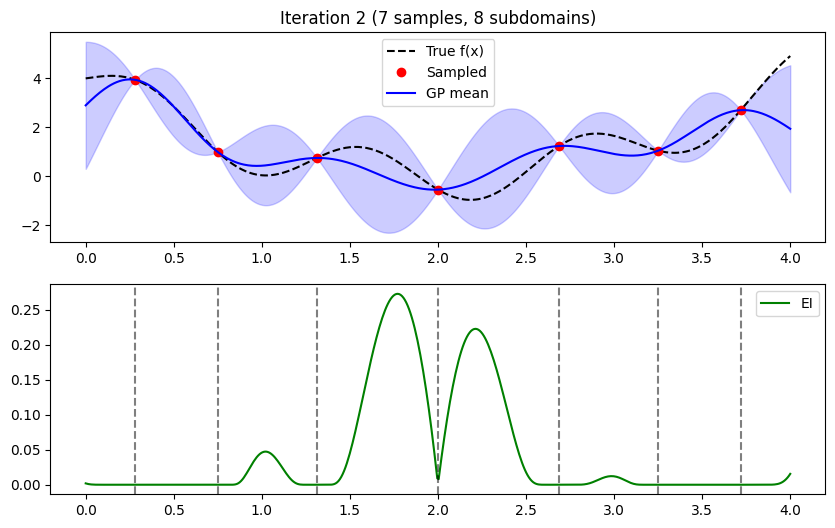

In [31]:
mu, sigma = gp.predict(xx, return_std=True)
ei = expected_improvement(xx, gp, np.min(y))

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(xx, f(xx), 'k--', label="True f(x)")
plt.plot(X, y, 'ro', label="Sampled")
plt.plot(xx, mu, 'b', label="GP mean")
plt.fill_between(xx.ravel(), mu-1.96*sigma, mu+1.96*sigma, alpha=0.2, color='b')
plt.legend(); plt.title("Iteration 2 (7 samples, 8 subdomains)")

plt.subplot(2,1,2)
plt.plot(xx, ei, 'g', label="EI")
for xvline in X.ravel():
    plt.axvline(xvline, color='k', ls='--', alpha=0.5) # subdomain split markers
#plt.axvline((a+x_c)/2, color='k', ls='--', alpha=0.5) # subdomain split markers
#plt.axvline((x_c+b)/2, color='k', ls='--', alpha=0.5)
#plt.axvline(x_c, color='k', ls=':')
plt.legend()
plt.show()

#### 2.6.4 - Show EI interval estimation in 8 subdomains

In [32]:
iy = 0
intervals3, sampledMask3, excludedMask3Pre = split_intervals(intervals2, excludedMask2Post, a, b)
for i in range(len(intervals3)):
    L,R = intervals3[i]
    if sampledMask3[i]:
        print(f"\nInterval [{L:.2f}, {R:.2f}] Sampled")
        yx = float(y.ravel()[iy])
        print(f"Value is f({0.5*(L+R):.2f}) = {yx:.4f}")
        if yx == float(y.min()):
            print("**** This is the current best value.")
        iy += 1
    else:
        mask = ((xx >= L) & (xx <= R)).ravel()

        out = ei_bounds_on_interval(L, R, gp)
        print(f"\nInterval [{L:.2f}, {R:.2f}]:")
        print("μ bounds :", out["mu_bounds"])
        print("Actual μ bounds :", (float(mu[mask].min()),float(mu[mask].max())))
        print("σ bounds :", out["sigma_bounds"])
        print("Q bounds :", out["Q_bounds"])
        print("EI bounds:", out["EI_bounds"])


Interval [0.00, 0.21]:
μ bounds : (2.7429253669842772, 4.081869842305904)
Actual μ bounds : (2.898710949641217, 3.921926734447997)
σ bounds : (0.0, 1.3787646611879099)
Q bounds : (1.8210127801009062, 3.9297671214968637)
EI bounds: (0.0, 0.003935938767772134)

Interval [0.21, 0.35] Sampled
Value is f(0.28) = 3.9406

Interval [0.35, 0.63]:
μ bounds : (1.6689569978408125, 3.867406111212389)
Actual μ bounds : (1.8372379332316333, 3.753537633771082)
σ bounds : (0.0, 1.560683836250681)
Q bounds : (1.2862707343073758, 5.99402238809063)
EI bounds: (0.0, 0.05500186492178005)

Interval [0.63, 0.87] Sampled
Value is f(0.75) = 0.9909

Interval [0.87, 1.17]:
μ bounds : (-0.2781734833533988, 1.4499370083665402)
Actual μ bounds : (0.42450841016122287, 0.6328844352068401)
σ bounds : (0.0, 1.7436515571220887)
Q bounds : (0.6816840183872332, 6.565803005936997)
EI bounds: (0.0, 0.5707619991012525)

Interval [1.17, 1.45] Sampled
Value is f(1.31) = 0.7484

Interval [1.45, 1.83]:
μ bounds : (-0.50637983310

## 3 - Optimization Loop

### 3.1 - 1D


Iteration 0:
intervals:
 [[-20  20]]
sampledMask: [0]
excludedMaskPost: [0]
x to sample:
 [[0.]]
y values:
 [[-1.4]]
Max EI over 38 random samples: 0.116642

Interval [-20.00, -5.00]:
μ bounds : (-2.7002484094705027e-22, 0.0)
Actual μ bounds : (-2.2094468018185333e-22, 0.0)
σ bounds : (1.3999993793106997, 1.3999993793106997)
Actual σ bounds : (1.3999993793106997, 1.3999993793106997)
Q bounds : (0.0, 7.291338727696401e-44)
EI bounds: (0.11664150863415443, 0.11664150863415443)
Actual EI bounds : (0.11664150863415437, 0.11664150863415437)

Interval [-5.00, 5.00] Sampled
Value is f(0.00) = -1.4000
**** This is the current best value.

Interval [5.00, 20.00]:
μ bounds : (-2.7002484094705027e-22, 0.0)
Actual μ bounds : (-2.2094468018185333e-22, 0.0)
σ bounds : (1.3999993793106997, 1.3999993793106997)
Actual σ bounds : (1.3999993793106997, 1.3999993793106997)
Q bounds : (0.0, 7.291338727696401e-44)
EI bounds: (0.11664150863415443, 0.11664150863415443)
Actual EI bounds : (0.11664150863415437,

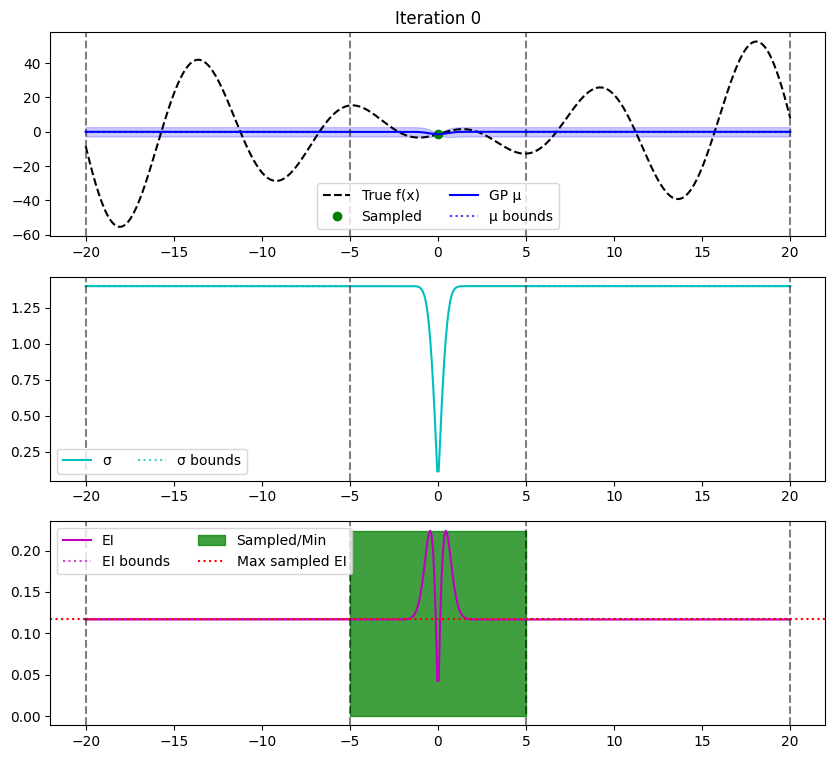


Iteration 1:
intervals:
 [[-20.  -5.]
 [ -5.   5.]
 [  5.  20.]]
sampledMask: [0 1 0]
excludedMaskPre: [0 0 0]
bounded EI on:
 [[-20.  -5.]
 [  5.  20.]]
excludedMaskPost: [0 0 0]
x to sample:
 [[-12.5]
 [  0. ]
 [ 12.5]]
y values:
 [[ 30.37489709]
 [ -1.4       ]
 [-28.18852918]]
Max EI over 33 random samples: 1.406529

Interval [-20.00, -14.38]:
μ bounds : (4.211003480541796e-48, 0.02684613307374079)
Actual μ bounds : (4.211003480541796e-48, 0.024201400069647074)
σ bounds : (23.93871551601009, 23.93872486586669)
Actual σ bounds : (23.938717267461676, 23.93872486586669)
Q bounds : (1.1013962604990297e-95, 0.00044764720177774145)
EI bounds: (1.3965900409203194, 1.412409295937766)
Actual EI bounds : (1.403215097738975, 1.40610605410135)

Interval [-14.38, -10.62] Sampled
Value is f(-12.50) = 30.3749

Interval [-10.62, -3.12]:
μ bounds : (-4.6111997463819235e-09, 0.02684613307374079)
Actual μ bounds : (-2.7412471381165506e-09, 0.026099396472942283)
σ bounds : (23.93871551601009, 23.9387

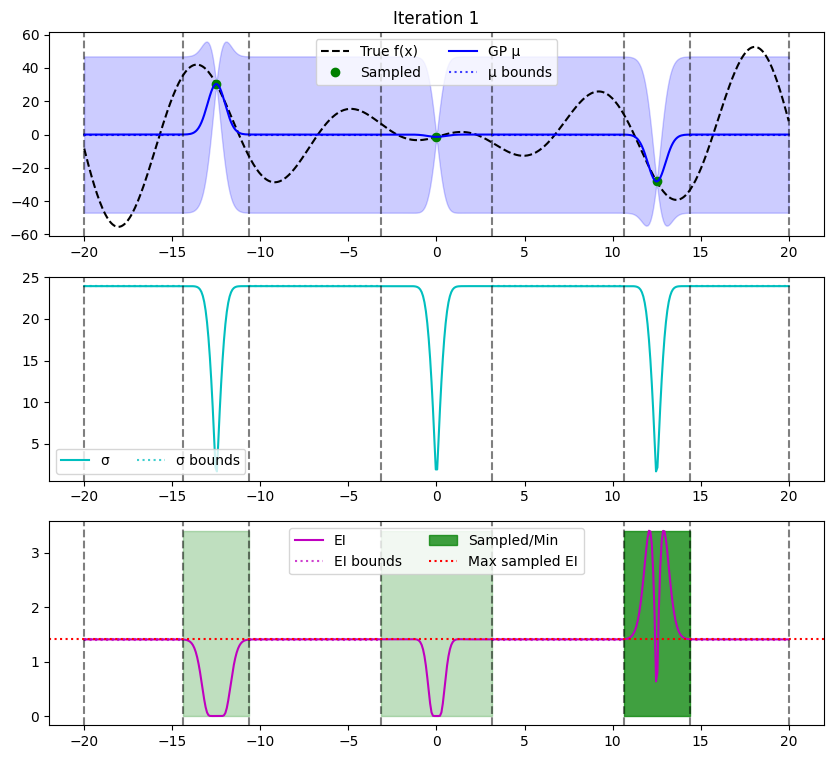


Iteration 2:
intervals:
 [[-20.    -14.375]
 [-14.375 -10.625]
 [-10.625  -3.125]
 [ -3.125   3.125]
 [  3.125  10.625]
 [ 10.625  14.375]
 [ 14.375  20.   ]]
sampledMask: [0 1 0 1 0 1 0]
excludedMaskPre: [0 0 0 0 0 0 0]
bounded EI on:
 [[-20.    -14.375]
 [-10.625  -3.125]
 [  3.125  10.625]
 [ 14.375  20.   ]]
excludedMaskPost: [0 0 0 0 0 0 0]
x to sample:
 [[-17.1875]
 [-12.5   ]
 [ -6.875 ]
 [  0.    ]
 [  6.875 ]
 [ 12.5   ]
 [ 17.1875]]
y values:
 [[-45.55872006]
 [ 30.37489709]
 [ -2.20126398]
 [ -1.4       ]
 [  1.92142111]
 [-28.18852918]
 [ 43.1501401 ]]
Max EI over 29 random samples: 1.494664

Interval [-20.00, -17.89]:
μ bounds : (-16.949401309908517, -6.136165903745324e-06)
Actual μ bounds : (-15.769347433870834, -6.136165903745324e-06)
σ bounds : (26.406523793343993, 28.448591319176153)
Actual σ bounds : (26.690061248480525, 28.448591319176153)
Q bounds : (1.4681576447563893e-11, 112.01784919707703)
EI bounds: (0.0, 5.63642676706985)
Actual EI bounds : (0.658959510112859

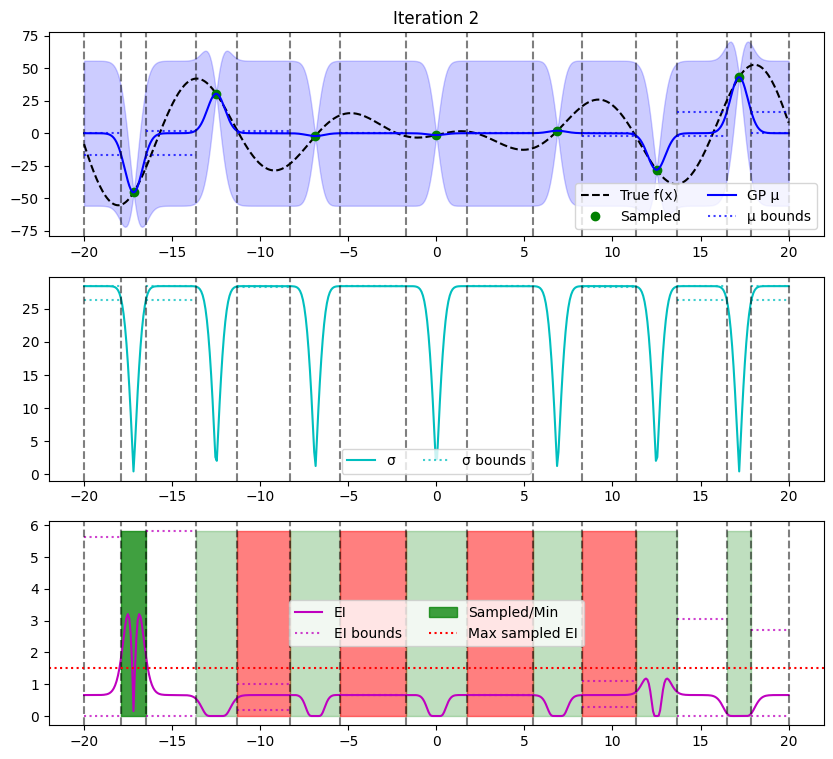


Iteration 3:
intervals:
 [[-20.       -17.890625]
 [-17.890625 -16.484375]
 [-16.484375 -13.671875]
 [-13.671875 -11.328125]
 [-11.328125  -8.28125 ]
 [ -8.28125   -5.46875 ]
 [ -5.46875   -1.71875 ]
 [ -1.71875    1.71875 ]
 [  1.71875    5.46875 ]
 [  5.46875    8.28125 ]
 [  8.28125   11.328125]
 [ 11.328125  13.671875]
 [ 13.671875  16.484375]
 [ 16.484375  17.890625]
 [ 17.890625  20.      ]]
sampledMask: [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
excludedMaskPre: [0 0 0 0 1 0 1 0 1 0 1 0 0 0 0]
bounded EI on:
 [[-20.       -17.890625]
 [-16.484375 -13.671875]
 [-11.328125  -8.28125 ]
 [ -5.46875   -1.71875 ]
 [  1.71875    5.46875 ]
 [  8.28125   11.328125]
 [ 13.671875  16.484375]
 [ 17.890625  20.      ]]
excludedMaskPost: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
x to sample:
 [[-18.9453125]
 [-17.1875   ]
 [-15.078125 ]
 [-12.5      ]
 [ -9.8046875]
 [ -6.875    ]
 [ -3.59375  ]
 [  0.       ]
 [  3.59375  ]
 [  6.875    ]
 [  9.8046875]
 [ 12.5      ]
 [ 15.078125 ]
 [ 17.1875   ]
 [ 18.9453125

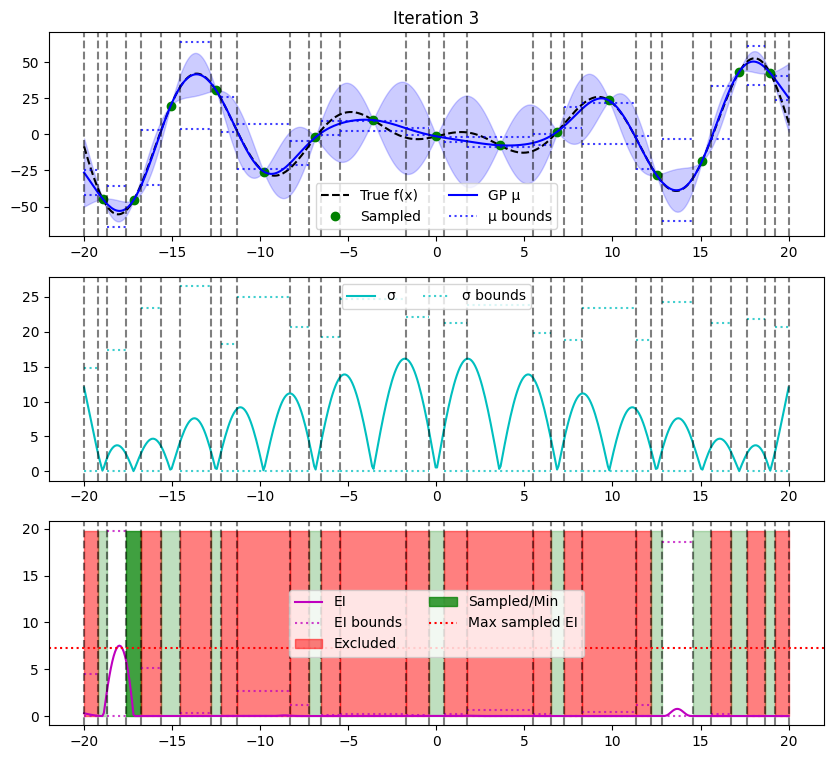

In [ ]:
# Function to minimiza
def f(x):
    #return (x - 8)**2 + 10*np.sin(5*x)
    #return (x+20)**2*(x-30)**2+0.05*(x-5)
    return -(1.4 - 3.0 * x) * np.cos(0.7 * x)

# Expected improvement function
def expected_improvement(X, gp, y_min):
    mu, sigma = gp.predict(X, return_std=True)
    sigma = sigma.reshape(-1,1)
    mu = mu.reshape(-1,1)
    with np.errstate(divide='warn'):
        Z = (y_min - mu) / sigma # to minimize
        ei = (y_min - mu) * norm.cdf(Z) + sigma * norm.pdf(Z) # to minimize
        ei[sigma==0.0] = 0.0
    return ei.ravel()

# Define domain, inital interval and masks
a, b = -20, 20
intervals = [np.array([(a,b)])]
excludedMaskPre = [np.array([0], dtype=bool)]
#excludedMaskPost = [np.array([0]*1, dtype=bool),np.array([0]*3, dtype=bool),np.array([0]*7, dtype=bool),np.array([0]*15, dtype=bool)]
excludedMaskPost = [np.array([0], dtype=bool)]
sampledMask = [np.array([0], dtype=bool)]

# Define gp
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6)

# Start iterations
for it in range(4):
    print("\n"+"="*40)
    print(f"Iteration {it}:")
    print("intervals:\n", intervals[it])
    print("sampledMask:", sampledMask[it].astype(int))
    if it>0:
        print("excludedMaskPre:", excludedMaskPre[it].astype(int))
        #print("bounded EI on:\n", intervals[it][np.logical_and(np.logical_not(excludedMaskPre[it]),np.logical_not(sampledMask[it]))])
        print("bounded EI on:\n", intervals[it][np.logical_not(sampledMask[it])])
    print("excludedMaskPost:", excludedMaskPost[it].astype(int))
    print("x to sample:\n", interval_midpoints(intervals[it][np.logical_not(excludedMaskPost[it])]))

    #X = interval_midpoints(intervals[it][np.logical_not(excludedMaskPost[it])])
    X = interval_midpoints(intervals[it])
    y = f(X)
    print("y values:\n", y)

    gp.fit(X, y)

    xx = np.linspace(a, b, 500).reshape(-1,1)
    mu, sigma = gp.predict(xx, return_std=True)
    ei = expected_improvement(xx, gp, np.min(y))

    iy = 0
    intervals_new, sampledMask_new, excludedMaskPost_new = split_intervals(intervals[it], excludedMaskPre[it], a, b)

    intervals_new_ne_ns = intervals_new[np.logical_and(np.logical_not(excludedMaskPost_new),np.logical_not(sampledMask_new))]
    mask_big = np.any((xx.ravel()[:, None] >= intervals_new_ne_ns[:, 0]) & (xx.ravel()[:, None] <= intervals_new_ne_ns[:, 1]), axis=1)
    
    xx_sample = np.random.choice(xx[mask_big].ravel(), size=int(round(0.1*mask_big.sum())), replace=False).reshape(-1,1)
    ei_sample = expected_improvement(xx_sample, gp, np.min(y))
    ei_sample_max = ei_sample.max()
    print(f"Max EI over {len(xx_sample)} random samples: {ei_sample_max:.6f}")

    excludedMaskPre_new = np.array([0]*len(intervals_new), dtype=bool)
    mu_bounds = []
    sigma_bounds = []
    ei_bounds = []
    max_ei_bound_max = 0
    max_ei_bound_max_i = 0
    for i in range(len(intervals_new)):
        L,R = intervals_new[i]
        if sampledMask_new[i]:
            print(f"\nInterval [{L:.2f}, {R:.2f}] Sampled")
            yx = float(y.ravel()[iy])
            print(f"Value is f({0.5*(L+R):.2f}) = {yx:.4f}")
            if yx == float(y.min()):
                min_y_i = i
                print("**** This is the current best value.")
            iy += 1
            mu_bounds.append(None)
            sigma_bounds.append(None)
            ei_bounds.append(None)
        else:
            mask = ((xx >= L) & (xx <= R)).ravel()

            out = ei_bounds_on_interval(L, R, gp)
            print(f"\nInterval [{L:.2f}, {R:.2f}]:")
            print("μ bounds :", out["mu_bounds"])
            mu_bounds.append(out["mu_bounds"])
            print("Actual μ bounds :", (float(mu[mask].min()),float(mu[mask].max())))
            print("σ bounds :", out["sigma_bounds"])
            sigma_bounds.append(out["sigma_bounds"])
            print("Actual σ bounds :", (float(sigma[mask].min()),float(sigma[mask].max())))
            print("Q bounds :", out["Q_bounds"])
            print("EI bounds:", out["EI_bounds"])
            ei_bounds.append(out["EI_bounds"])
            print("Actual EI bounds :", (float(ei[mask].min()),float(ei[mask].max())))
            ei_bound_max = out["EI_bounds"][1]
            if ei_bound_max > max_ei_bound_max:
                max_ei_bound_max = ei_bound_max
            if ei_bound_max < ei_sample_max:
                print(f"**** Excluding this interval since EI bound {ei_bound_max:.6f} < sampled max EI {ei_sample_max:.6f}")
                excludedMaskPre_new[i] = True

    intervals.append(intervals_new)
    sampledMask.append(sampledMask_new)
    excludedMaskPre.append(excludedMaskPre_new)
    excludedMaskPost.append(excludedMaskPost_new)


    xSplitMarkers = np.unique(intervals_new)

    fig = plt.figure(figsize=(10,9))
    plt.subplot(3,1,1)
    plt.plot(xx, f(xx), 'k--', label="True f(x)")
    plt.plot(X, y, 'go', label="Sampled")
    plt.plot(xx, mu, 'b', label="GP μ")
    plt.fill_between(xx.ravel(), mu-1.96*sigma, mu+1.96*sigma, alpha=0.2, color='b')
    for xvline in xSplitMarkers:
        plt.axvline(xvline, color='k', ls='--', alpha=0.5) # subdomain split markers
    for i in range(len(mu_bounds)):
        if not(sampledMask_new[i]):
            L,R = intervals_new[i]
            B,T = mu_bounds[i]
            plt.plot([L,R], [B,B], 'b:', alpha=0.75, label="μ bounds" if i==0 else None)
            plt.plot([L,R], [T,T], 'b:', alpha=0.75)
        #else:
            #L,R = intervals_new[i]
            #plt.fill_betweenx([f(xx).min(), f(xx).max()], L, R, color='green', alpha=0.25, label="Sampled" if i==0 else None)
    plt.legend(ncol=2); plt.title(f"Iteration {it}")

    plt.subplot(3,1,2)
    plt.plot(xx, sigma, 'c', label="σ")
    for i in range(len(sigma_bounds)):
        if not(sampledMask_new[i]):
            L,R = intervals_new[i]
            B,T = sigma_bounds[i]
            plt.plot([L,R], [B,B], 'c:', alpha=0.75, label="σ bounds" if i==0 else None)
            plt.plot([L,R], [T,T], 'c:', alpha=0.75)
    for xvline in xSplitMarkers:
        plt.axvline(xvline, color='k', ls='--', alpha=0.5) # subdomain split markers
    plt.legend(ncol=2)
    
    plt.subplot(3,1,3)
    plt.plot(xx, ei, 'm', label="EI")
    for i in range(len(ei_bounds)):
        if not(sampledMask_new[i]):
            L,R = intervals_new[i]
            B,T = ei_bounds[i]
            plt.plot([L,R], [B,B], 'm:', alpha=0.75, label="EI bounds" if i==0 else None)
            plt.plot([L,R], [T,T], 'm:', alpha=0.75)
            if T < ei_sample_max:
                plt.fill_betweenx([0, max(ei.max(),max_ei_bound_max)], L, R, color='r', alpha=0.5, label="Excluded" if i==0 else None)
        else:
            L,R = intervals_new[i]
            plt.fill_betweenx([0, max(ei.max(),max_ei_bound_max)], L, R, color='g', alpha=0.75 if i==min_y_i else 0.25, label="Sampled/Min" if i==min_y_i else None)
    for xvline in xSplitMarkers:
        plt.axvline(xvline, color='k', ls='--', alpha=0.5) # subdomain split markers
    plt.axhline(ei_sample_max, color='r', ls=':', label="Max sampled EI")
    plt.legend(ncol=2)
    plt.show()
    fig.savefig(f"Figures/eBO_it{it}.png", dpi=150, bbox_inches='tight')

### 3.2 - MD

Function to minimize:


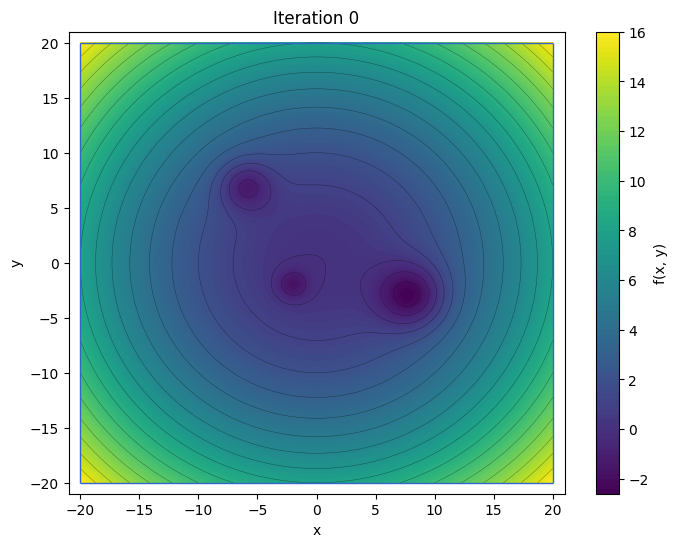


Iteration 1:
intervals:
 [[[-20  20]
  [-20  20]]]
sampledMask: [0]
excludedMaskPost: [0]
X to sample:
 [[0. 0.]]
y values:
 [-0.03706704]
Max EI over 15000 random samples: 0.012616

Box [[-20.  -5.]
 [-20.  20.]]:
μ bounds : (-0.03706703705502019, -0.03706703705502019)
Actual μ bounds : (-0.03706703705502019, -0.03706703705502019)

Box [[ -5.   5.]
 [-20.  -5.]]:
μ bounds : (-0.03706703705502019, -0.03706703705502019)
Actual μ bounds : (-0.03706703705502019, -0.03706703705502019)

Box [[-5.  5.]
 [-5.  5.]] sampled
Value is f([0. 0.]) = -0.0371
**** This is the current best value.

Box [[-5.  5.]
 [ 5. 20.]]:
μ bounds : (-0.03706703705502019, -0.03706703705502019)
Actual μ bounds : (-0.03706703705502019, -0.03706703705502019)

Box [[  5.  20.]
 [-20.  20.]]:
μ bounds : (-0.03706703705502019, -0.03706703705502019)
Actual μ bounds : (-0.03706703705502019, -0.03706703705502019)


/Users/juanesfco/tamubo/venvs/venv313/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


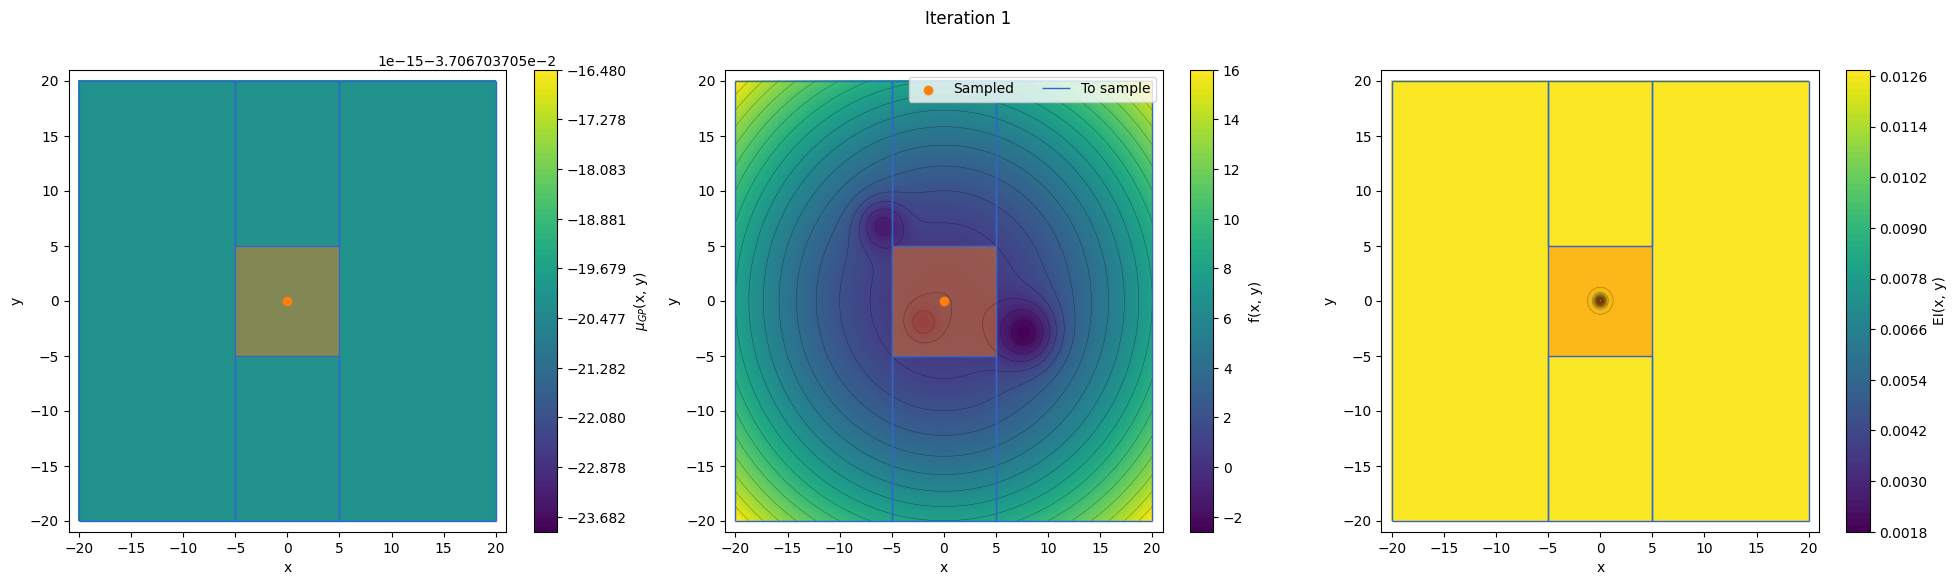


Iteration 2:
intervals:
 [[[-20.  -5.]
  [-20.  20.]]

 [[ -5.   5.]
  [-20.  -5.]]

 [[ -5.   5.]
  [ -5.   5.]]

 [[ -5.   5.]
  [  5.  20.]]

 [[  5.  20.]
  [-20.  20.]]]
sampledMask: [0 0 1 0 0]
excludedMaskPre: [0 0 0 0 0]
bounded EI on:
 [[[-20.  -5.]
  [-20.  20.]]

 [[ -5.   5.]
  [-20.  -5.]]

 [[ -5.   5.]
  [  5.  20.]]

 [[  5.  20.]
  [-20.  20.]]]
excludedMaskPost: [0 0 0 0 0]
X to sample:
 [[-12.5   0. ]
 [  0.  -12.5]
 [  0.    0. ]
 [  0.   12.5]
 [ 12.5   0. ]]
y values:
 [ 3.12499996  3.12499998 -0.03706704  3.12499472  3.02168324]
Max EI over 15025 random samples: 0.013228

Box [[-20.    -14.375]
 [-20.     20.   ]]:
μ bounds : (2.4719221732354137, 2.472499379990528)
Actual μ bounds : (2.4719221732354137, 2.472451019690826)

Box [[-14.375 -10.625]
 [-20.     -5.   ]]:
μ bounds : (2.4719221732354137, 2.4719221732354137)
Actual μ bounds : (2.4719221732354137, 2.4719221732354137)

Box [[-14.375 -10.625]
 [ -5.      5.   ]] sampled
Value is f([-12.5   0. ]) = 3.1250



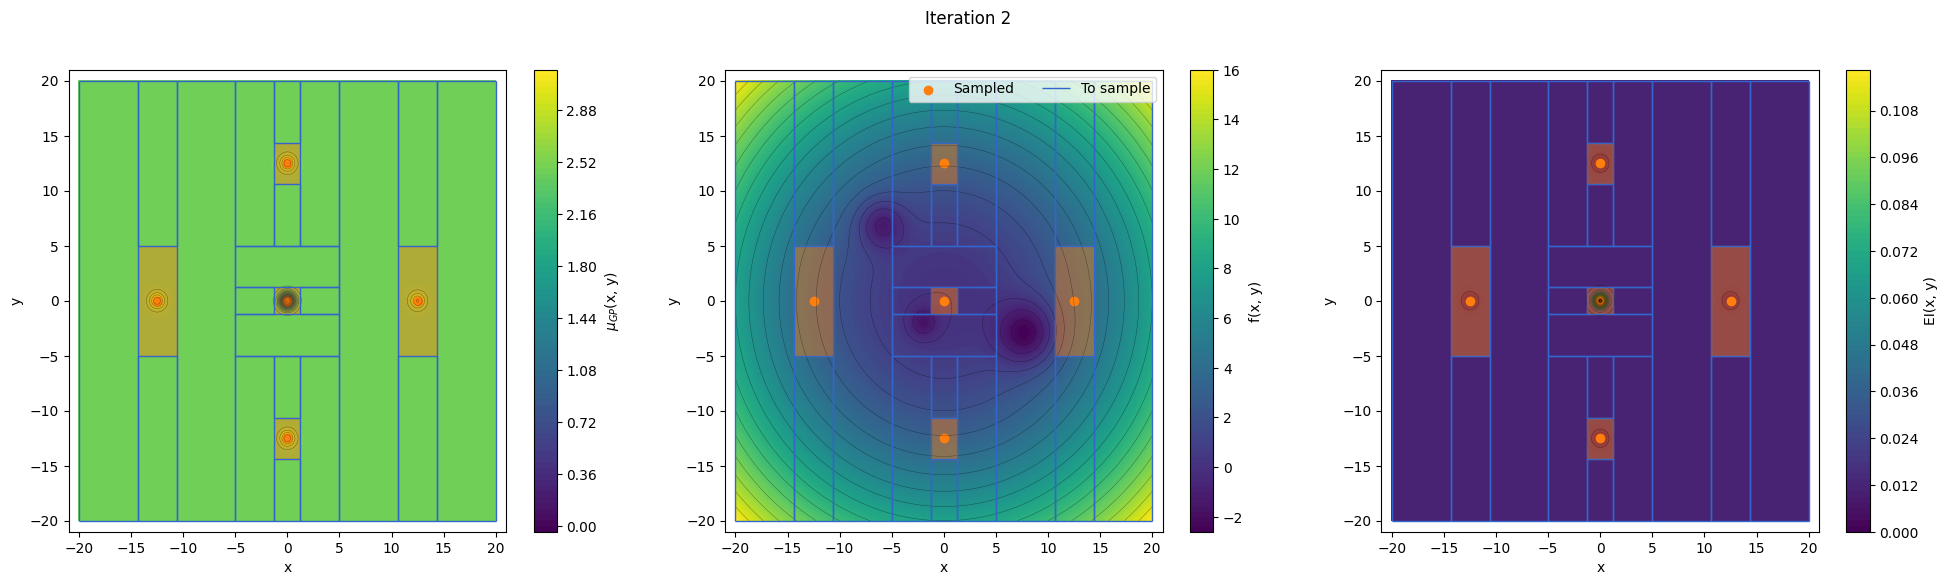


Iteration 3:
intervals:
 [[[-20.    -14.375]
  [-20.     20.   ]]

 [[-14.375 -10.625]
  [-20.     -5.   ]]

 [[-14.375 -10.625]
  [ -5.      5.   ]]

 [[-14.375 -10.625]
  [  5.     20.   ]]

 [[-10.625  -5.   ]
  [-20.     20.   ]]

 [[ -5.     -1.25 ]
  [-20.     -5.   ]]

 [[ -1.25    1.25 ]
  [-20.    -14.375]]

 [[ -1.25    1.25 ]
  [-14.375 -10.625]]

 [[ -1.25    1.25 ]
  [-10.625  -5.   ]]

 [[  1.25    5.   ]
  [-20.     -5.   ]]

 [[ -5.      5.   ]
  [ -5.     -1.25 ]]

 [[ -5.     -1.25 ]
  [ -1.25    1.25 ]]

 [[ -1.25    1.25 ]
  [ -1.25    1.25 ]]

 [[  1.25    5.   ]
  [ -1.25    1.25 ]]

 [[ -5.      5.   ]
  [  1.25    5.   ]]

 [[ -5.     -1.25 ]
  [  5.     20.   ]]

 [[ -1.25    1.25 ]
  [  5.     10.625]]

 [[ -1.25    1.25 ]
  [ 10.625  14.375]]

 [[ -1.25    1.25 ]
  [ 14.375  20.   ]]

 [[  1.25    5.   ]
  [  5.     20.   ]]

 [[  5.     10.625]
  [-20.     20.   ]]

 [[ 10.625  14.375]
  [-20.     -5.   ]]

 [[ 10.625  14.375]
  [ -5.      5.   ]]

 [[ 10.6

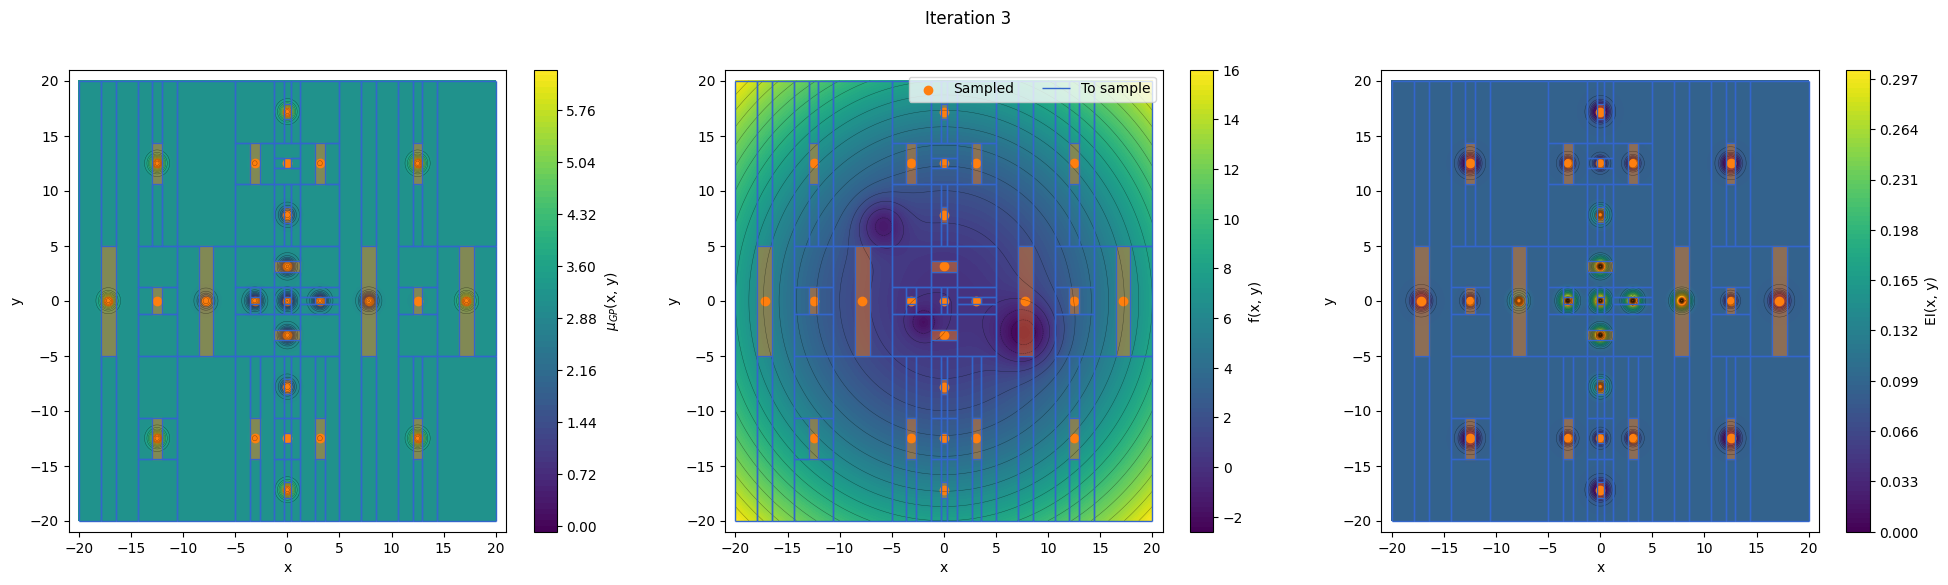


Iteration 4:
intervals:
 [[[-20.       -17.890625]
  [-20.        20.      ]]

 [[-17.890625 -16.484375]
  [-20.        -5.      ]]

 [[-17.890625 -16.484375]
  [ -5.         5.      ]]

 [[-17.890625 -16.484375]
  [  5.        20.      ]]

 [[-16.484375 -14.375   ]
  [-20.        20.      ]]

 [[-14.375    -10.625   ]
  [-20.       -14.375   ]]

 [[-14.375    -12.96875 ]
  [-14.375    -10.625   ]]

 [[-12.96875  -12.03125 ]
  [-14.375    -10.625   ]]

 [[-12.03125  -10.625   ]
  [-14.375    -10.625   ]]

 [[-14.375    -10.625   ]
  [-10.625     -5.      ]]

 [[-14.375    -10.625   ]
  [ -5.        -1.25    ]]

 [[-14.375    -12.96875 ]
  [ -1.25       1.25    ]]

 [[-12.96875  -12.03125 ]
  [ -1.25       1.25    ]]

 [[-12.03125  -10.625   ]
  [ -1.25       1.25    ]]

 [[-14.375    -10.625   ]
  [  1.25       5.      ]]

 [[-14.375    -12.96875 ]
  [  5.        20.      ]]

 [[-12.96875  -12.03125 ]
  [  5.        10.625   ]]

 [[-12.96875  -12.03125 ]
  [ 10.625     14.375   ]]

 [

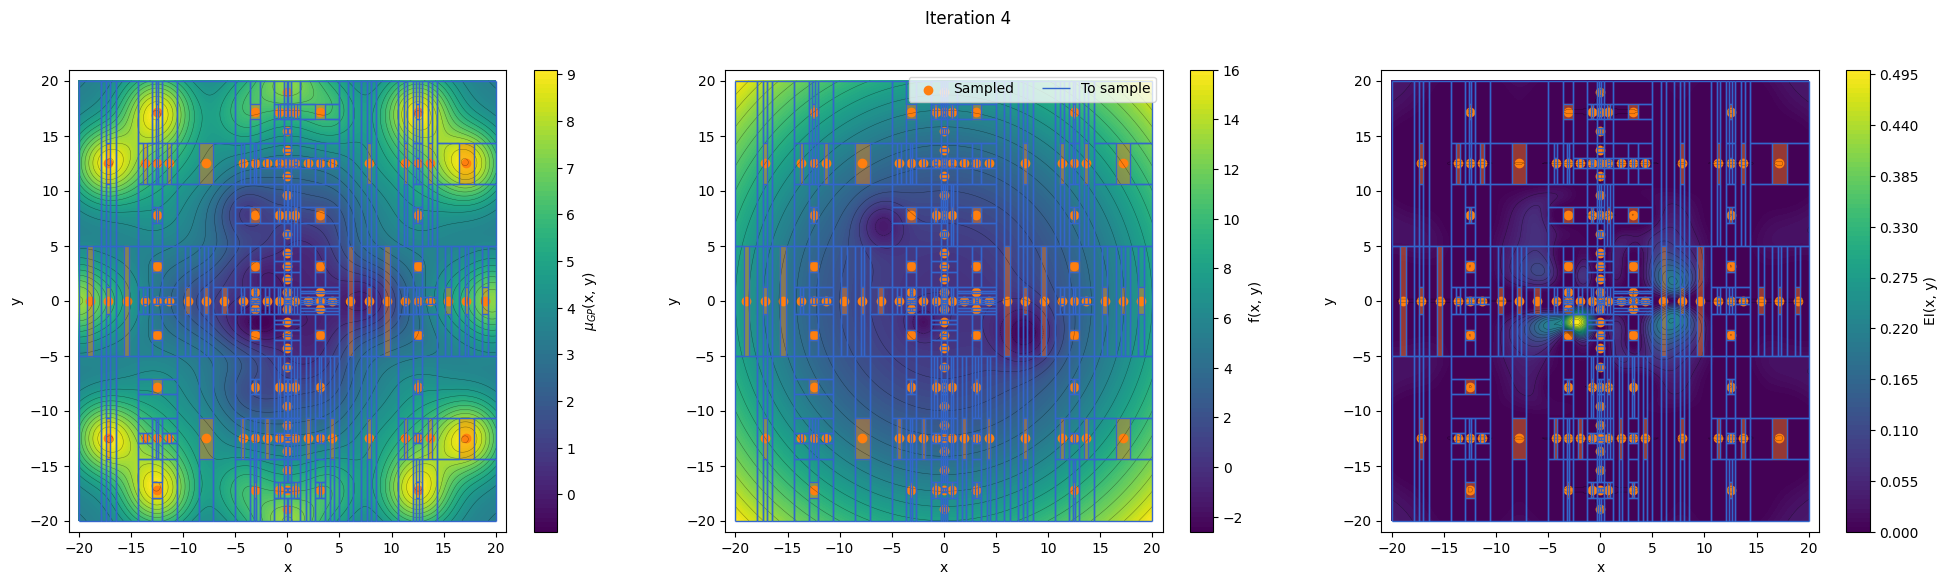

In [114]:
# Plot parameters
colormap = 'viridis'
colorToSample = "#3366CC"
colorSampled = "#FF7F0E"
colorExcluded = "#D62728"
contourfLevels = 100

# Expected improvement function
def expected_improvement(X, gp, y_min):
    mu, sigma = gp.predict(X, return_std=True)
    sigma = sigma.reshape(-1,1)
    mu = mu.reshape(-1,1)
    with np.errstate(divide='warn'):
        Z = (y_min - mu) / sigma # to minimize
        ei = (y_min - mu) * norm.cdf(Z) + sigma * norm.pdf(Z) # to minimize
        ei[sigma==0.0] = 0.0
    return ei.ravel()

# Function to minimiza
def f(X):
    x, y = X[:,0], X[:,1]

    # Parameters
    alpha = 0.02
    A  = np.array([4.0, 3.0, 2.0])
    B  = np.array([8.0, 5.0, 2.0])    # betas
    C  = np.array([[ 8.0, -3.0],      # centers (x1,y1)
                [-6.0,  7.0],
                [-2.0, -2.0]])
    
    # Compute function value
    val = alpha*(x**2 + y**2)
    for Ai, Bi, (xi, yi) in zip(A, B, C):
        r2 = (x - xi)**2 + (y - yi)**2
        val -= Ai * np.exp(-r2 / Bi)
    return val

# Define domain for both axis
a, b = -20, 20

# Create grid for intial function plot
N = 400
x = np.linspace(a, b, N)
y = np.linspace(a, b, N)
XX, YY = np.meshgrid(x, y)
xx = np.vstack([XX.ravel(),YY.ravel()]).T
ZZ = f(xx)
ZZ = ZZ.reshape((N, N))

# Define inital interval and masks
intervals = [np.array([[[a,b],
                        [a,b]]])]
excludedMaskPre = [np.array([0], dtype=bool)]
#excludedMaskPost = [np.array([0]*1, dtype=bool),np.array([0]*3, dtype=bool),np.array([0]*7, dtype=bool),np.array([0]*15, dtype=bool)]
excludedMaskPost = [np.array([0], dtype=bool)]
sampledMask = [np.array([0], dtype=bool)]

# --- Plot ---
print("Function to minimize:")
fig = plt.figure(figsize=(8, 6))
plt.contourf(XX, YY, ZZ, levels=contourfLevels, cmap=colormap)
plt.colorbar(label='f(x, y)')
plt.contour(XX, YY, ZZ, levels=20, colors='k', linewidths=0.3, alpha=0.5)
box = intervals[0][0]
Lx, Ly = box[:,0]
Rx, Ry = box[:,1]
plt.vlines(Lx, Ly, Ry, color=colorToSample, linewidth=1)
plt.vlines(Rx, Ly, Ry, color=colorToSample, linewidth=1)
plt.hlines(Ly, Lx, Rx, color=colorToSample, linewidth=1)
plt.hlines(Ry, Lx, Rx, color=colorToSample, linewidth=1)
plt.xlim(a-1, b+1)
plt.ylim(a-1, b+1)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Iteration 0")
plt.show()
fig.savefig("Figures/eBO_MD_it0.png", dpi=150, bbox_inches='tight')

# Define gp
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.5, length_scale_bounds=(1e-1, 1e3))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True)

# Start iterations
for it in range(4):
    # Prints to understand what its happening
    print("\n"+"="*40)
    print(f"Iteration {it+1}:")
    print("intervals:\n", intervals[it])
    print("sampledMask:", sampledMask[it].astype(int))
    if it>0:
        print("excludedMaskPre:", excludedMaskPre[it].astype(int))
        #print("bounded EI on:\n", intervals[it][np.logical_and(np.logical_not(excludedMaskPre[it]),np.logical_not(sampledMask[it]))])
        print("bounded EI on:\n", intervals[it][np.logical_not(sampledMask[it])])
    print("excludedMaskPost:", excludedMaskPost[it].astype(int))
    print("X to sample:\n", hyperboxes_midpoints(intervals[it][np.logical_not(excludedMaskPost[it])]))

    # X to sample in this iteration
    X = hyperboxes_midpoints(intervals[it][np.logical_not(excludedMaskPost[it])])
    y = f(X) # Sampling
    print("y values:\n", y)

    # Fitting gp to this values
    gp.fit(X, y)

    # Calculate mu, sigma and ei in whole domain (for comparison with bounds)
    mu, sigma = gp.predict(xx, return_std=True)
    ei = expected_improvement(xx, gp, np.min(y))

    # Obtain axis order for partition
    n,m,_ = intervals[it].shape
    rng = np.random.default_rng(it) # For reproducibility
    dirOrd = np.vstack([rng.permutation(m) for _ in range(n)]) # n random permutations of [0,1,...,m-1]

    # Partition algorithm
    intervals_new, sampledMask_new, excludedMaskPost_new = hyperboxes_partition(intervals[it], excludedMaskPre[it], dirOrd)

    # Take a sample to find EI threshold, use values in non-excluded/non-sampled intervals
    intervals_new_ne_ns = intervals_new[np.logical_and(np.logical_not(excludedMaskPost_new),np.logical_not(sampledMask_new))]
    mask_big = hypermask(intervals_new_ne_ns,xx) # Find hypermask
    xx_sample = rng.choice(xx[mask_big], size=int(round(0.1*mask_big.sum())), replace=False) # Sample 10% of values randomly
    ei_sample = expected_improvement(xx_sample, gp, np.min(y))
    ei_sample_max = ei_sample.max()
    print(f"Max EI over {len(xx_sample)} random samples: {ei_sample_max:.6f}")

    # Create new array for exclude mask to fill up with EI threshold rule
    excludedMaskPre_new = np.array([0]*len(intervals_new), dtype=bool)
    
    # To document bounds and values
    mu_bounds = []
    sigma_bounds = []
    ei_bounds = []
    max_ei_bound_max = 0
    max_ei_bound_max_i = 0

    # Index to find sampled values
    iy = 0
    for i in range(len(intervals_new)):
        box = intervals_new[i]
        L = box[:,0]
        R = box[:,1]
        #Lx, Ly = box[:,0]
        #Rx, Ry = box[:,1]
        if sampledMask_new[i]:
            print(f"\nBox {box} sampled")
            yx = float(y.ravel()[iy])
            print(f"Value is f({X[iy]}) = {yx:.4f}")
            if yx == float(y.min()):
                min_y_i = i
                print("**** This is the current best value.")
            iy += 1
            mu_bounds.append(None)
            sigma_bounds.append(None)
            ei_bounds.append(None)
        else:
            mask = hypermask(np.array([box]),xx)
            mu_bounds_only = gp_mu_interval_bounds_MD(L, R, gp)[:2]

            #out = ei_bounds_on_interval(L, R, gp)
            print(f"\nBox {box}:")
            #print("μ bounds :", out["mu_bounds"])
            print("μ bounds :", mu_bounds_only)
            #mu_bounds.append(out["mu_bounds"])
            mu_bounds.append(mu_bounds_only)
            print("Actual μ bounds :", (float(mu[mask].min()),float(mu[mask].max())))
            """
            print("σ bounds :", out["sigma_bounds"])
            sigma_bounds.append(out["sigma_bounds"])
            print("Actual σ bounds :", (float(sigma[mask].min()),float(sigma[mask].max())))
            print("Q bounds :", out["Q_bounds"])
            print("EI bounds:", out["EI_bounds"])
            ei_bounds.append(out["EI_bounds"])
            print("Actual EI bounds :", (float(ei[mask].min()),float(ei[mask].max())))
            ei_bound_max = out["EI_bounds"][1]
            if ei_bound_max > max_ei_bound_max:
                max_ei_bound_max = ei_bound_max
            if ei_bound_max < ei_sample_max:
                print(f"**** Excluding this interval since EI bound {ei_bound_max:.6f} < sampled max EI {ei_sample_max:.6f}")
                excludedMaskPre_new[i] = True
            """
    
    # Saving
    intervals.append(intervals_new)
    sampledMask.append(sampledMask_new)
    excludedMaskPre.append(excludedMaskPre_new)
    excludedMaskPost.append(excludedMaskPost_new)

    # Plotting
    fig = plt.figure(figsize=(24,6))
    plt.suptitle(f"Iteration {it+1}")
    plt.subplot(1,3,1)
    plt.contourf(XX, YY, mu.reshape((N,N)), levels=contourfLevels, cmap=colormap)
    plt.colorbar(label=r"$\mu_{GP}$(x, y)")
    plt.contour(XX, YY, mu.reshape((N,N)), levels=20, colors='k', linewidths=0.3, alpha=0.5)
    plt.scatter(X[:,0], X[:,1], color=colorSampled, marker='o', label="Sampled")
    # Plot partitions
    legExcMark = True
    legSamMark = True
    for i in range(len(intervals_new)):
        box = intervals_new[i]
        Lx, Ly = box[:,0]
        Rx, Ry = box[:,1]
        if excludedMaskPost_new[i]:
            plt.vlines(Lx, Ly, Ry, color=colorExcluded, linewidth=1, label="Excluded" if legExcMark else None)
            plt.vlines(Rx, Ly, Ry, color=colorExcluded, linewidth=1)
            plt.hlines(Ly, Lx, Rx, color=colorExcluded, linewidth=1)
            plt.hlines(Ry, Lx, Rx, color=colorExcluded, linewidth=1)
            legExcMark = False
        else:
            if sampledMask_new[i]:
                plt.fill_betweenx([Ly, Ry], Lx, Rx, color=colorSampled, alpha=0.25)
                plt.fill_between([Lx, Rx], Ly, Ry, color=colorSampled, alpha=0.25)
            else:
                plt.vlines(Lx, Ly, Ry, color=colorToSample, linewidth=1, label="To sample" if legSamMark else None)
                plt.vlines(Rx, Ly, Ry, color=colorToSample, linewidth=1)
                plt.hlines(Ly, Lx, Rx, color=colorToSample, linewidth=1)
                plt.hlines(Ry, Lx, Rx, color=colorToSample, linewidth=1)
                legSamMark = False
    plt.xlim(a-1, b+1)
    plt.ylim(a-1, b+1)
    plt.xlabel("x")
    plt.ylabel("y")
    #plt.legend(ncol=2)

    plt.subplot(1,3,2)
    plt.contourf(XX, YY, ZZ, levels=contourfLevels, cmap=colormap)
    plt.colorbar(label='f(x, y)')
    plt.contour(XX, YY, ZZ, levels=20, colors='k', linewidths=0.3, alpha=0.5)
    plt.scatter(X[:,0], X[:,1], color=colorSampled, marker='o', label="Sampled")
    # Plot partitions
    legExcMark = True
    legSamMark = True
    for i in range(len(intervals_new)):
        box = intervals_new[i]
        Lx, Ly = box[:,0]
        Rx, Ry = box[:,1]
        if excludedMaskPost_new[i]:
            plt.vlines(Lx, Ly, Ry, color=colorExcluded, linewidth=1, label="Excluded" if legExcMark else None)
            plt.vlines(Rx, Ly, Ry, color=colorExcluded, linewidth=1)
            plt.hlines(Ly, Lx, Rx, color=colorExcluded, linewidth=1)
            plt.hlines(Ry, Lx, Rx, color=colorExcluded, linewidth=1)
            legExcMark = False
        else:
            if sampledMask_new[i]:
                plt.fill_betweenx([Ly, Ry], Lx, Rx, color=colorSampled, alpha=0.25)
                plt.fill_between([Lx, Rx], Ly, Ry, color=colorSampled, alpha=0.25)
            else:
                plt.vlines(Lx, Ly, Ry, color=colorToSample, linewidth=1, label="To sample" if legSamMark else None)
                plt.vlines(Rx, Ly, Ry, color=colorToSample, linewidth=1)
                plt.hlines(Ly, Lx, Rx, color=colorToSample, linewidth=1)
                plt.hlines(Ry, Lx, Rx, color=colorToSample, linewidth=1)
                legSamMark = False
    plt.xlim(a-1, b+1)
    plt.ylim(a-1, b+1)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend(ncol=2)

    plt.subplot(1,3,3)
    plt.contourf(XX, YY, ei.reshape((N,N)), levels=contourfLevels, cmap=colormap)
    plt.colorbar(label='EI(x, y)')
    plt.contour(XX, YY, ei.reshape((N,N)), levels=20, colors='k', linewidths=0.3, alpha=0.5)
    plt.scatter(X[:,0], X[:,1], color=colorSampled, marker='o', label="Sampled")
    # Plot partitions
    legExcMark = True
    legSamMark = True
    for i in range(len(intervals_new)):
        box = intervals_new[i]
        Lx, Ly = box[:,0]
        Rx, Ry = box[:,1]
        if excludedMaskPost_new[i]:
            plt.vlines(Lx, Ly, Ry, color=colorExcluded, linewidth=1, label="Excluded" if legExcMark else None)
            plt.vlines(Rx, Ly, Ry, color=colorExcluded, linewidth=1)
            plt.hlines(Ly, Lx, Rx, color=colorExcluded, linewidth=1)
            plt.hlines(Ry, Lx, Rx, color=colorExcluded, linewidth=1)
            legExcMark = False
        else:
            if sampledMask_new[i]:
                plt.fill_betweenx([Ly, Ry], Lx, Rx, color=colorSampled, alpha=0.25)
                plt.fill_between([Lx, Rx], Ly, Ry, color=colorSampled, alpha=0.25)
            else:
                plt.vlines(Lx, Ly, Ry, color=colorToSample, linewidth=1, label="To sample" if legSamMark else None)
                plt.vlines(Rx, Ly, Ry, color=colorToSample, linewidth=1)
                plt.hlines(Ly, Lx, Rx, color=colorToSample, linewidth=1)
                plt.hlines(Ry, Lx, Rx, color=colorToSample, linewidth=1)
                legSamMark = False
    plt.xlim(a-1, b+1)
    plt.ylim(a-1, b+1)
    plt.xlabel("x")
    plt.ylabel("y")
    #plt.legend(ncol=2)
    plt.show()
    fig.savefig(f"Figures/eBO_MD_it{it+1}.png", dpi=150, bbox_inches='tight')